In [1]:
import warnings
warnings.filterwarnings("ignore")
# 1. 기본 라이브러리
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.model_selection import train_test_split

# 부스팅 모델
import xgboost as xgb
import lightgbm as lgb

# 딥러닝 모델
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, Dataset
import pytorch_lightning as pl
from pytorch_forecasting import TimeSeriesDataSet, TemporalFusionTransformer

# 샘플 데이터 생성

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from dataclasses import dataclass
from typing import Tuple, Dict

# 1) 날짜 인덱스 생성: 2023-01-01 ~ 2025-09-30, 평일만, 09~18시
date_range_full = pd.date_range(start="2023-01-01 00:00", end="2025-09-30 23:00", freq="1h")
date_range = date_range_full[(date_range_full.hour >= 9) & (date_range_full.hour <= 18) & (date_range_full.dayofweek < 5)]

# 2) 기본 feature 생성
N = len(date_range)
feature1 = np.random.normal(50, 10, N)
feature2 = np.random.normal(30,  5, N)

# 3) target 기본값(노이즈 포함)
target_base = np.random.normal(100, 15, N)

# 4) 시즌/시간대 부스트
def seasonal_multiplier(ts):
    year, month, hour = ts.year, ts.month, ts.hour
    mult = 1.0
    # 2023년 10~12월: 붐빔
    if year == 2023 and month in [10, 11, 12]:
        mult *= 1.5
    # 2024년 2분기(4~6월), 4분기(10~12월): 붐빔
    if year == 2024 and month in [4, 5, 6, 10, 11, 12]:
        mult *= 1.7
    # 오전(09~12시) 붐빔
    if 9 <= hour <= 12:
        mult *= 1.3
    return mult

mults = np.array([seasonal_multiplier(ts) for ts in date_range])

# 5) feature를 target과 약간 상관있게(현실감)
#   feature1은 양의 상관, feature2는 약한 음의 상관을 주되, 독립성도 일부 유지
target_trend = target_base * mults
feature1 = feature1 + 0.15 * target_trend / 10.0
feature2 = feature2 - 0.05 * target_trend / 10.0

# 최종 target
target = target_trend

# DataFrame 구성
df = pd.DataFrame(
    {
        "feature1": feature1,
        "feature2": feature2,
        "target":   target,
    },
    index=pd.DatetimeIndex(date_range, name="timestamp")
)

# 편의 feature
df["hour"] = df.index.hour
df["dayofweek"] = df.index.dayofweek

print(df.head(3), "\n...", "\n", df.tail(3))
print("총 샘플 수:", len(df))

                      feature1   feature2      target  hour  dayofweek
timestamp                                                             
2023-01-02 09:00:00  37.140937  26.422659   98.461927     9          0
2023-01-02 10:00:00  48.390081  39.217792  161.995727    10          0
2023-01-02 11:00:00  64.242996  38.812297  123.736144    11          0 
... 
                       feature1   feature2      target  hour  dayofweek
timestamp                                                             
2025-09-30 16:00:00  57.509580  21.655840  118.711210    16          1
2025-09-30 17:00:00  55.268918  33.567216  104.883261    17          1
2025-09-30 18:00:00  43.578876  32.343161  101.627190    18          1
총 샘플 수: 7170


# 전처리

In [3]:
# 시간지연/롤링 특징 (누설 방지)
def add_time_features(frame: pd.DataFrame, target_col="target") -> pd.DataFrame:
    out = frame.copy()
    # Lags
    for lag in [1, 2, 3, 24]:  # 바로 전, 2,3시간 전 + 하루 전(업무시간 기준)
        out[f"{target_col}_lag{lag}"] = out[target_col].shift(lag)
    # Rolling means (최근 흐름)
    for w in [3, 6]:
        out[f"{target_col}_rmean{w}"] = out[target_col].shift(1).rolling(w).mean()
    return out

df_b = add_time_features(df)

# 결측(초기 lag/rolling) 제거
df_b = df_b.dropna().copy()

# 시간기반 분할: 최근 60 영업일을 테스트로 (필요 시 조정)
# 영업일 기준 1일 10샘플(09~18시) → 약 600 샘플
test_days = 60
hours_per_day = 10
test_len = test_days * hours_per_day
train_df = df_b.iloc[:-test_len]
test_df  = df_b.iloc[-test_len:]

# Boosting 입력/타깃
boost_cols = [
    "feature1","feature2","hour","dayofweek",
    "target_lag1","target_lag2","target_lag3","target_lag24",
    "target_rmean3","target_rmean6",
]
X_train_b, y_train_b = train_df[boost_cols], train_df["target"]
X_test_b,  y_test_b  = test_df[boost_cols],  test_df["target"]

print("Train:", X_train_b.shape, "Test:", X_test_b.shape)

Train: (6546, 10) Test: (600, 10)


# 모델링

## ML(Boost)

In [4]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import warnings
try:
    3import lightgbm as lgb
    lgbm = lgb.LGBMRegressor(
        n_estimators=600,
        learning_rate=0.05,
        subsample=0.9,
        colsample_bytree=0.8,
        random_state=42,
        # GPU 사용 가능 시:
        device="gpu"
    )
except Exception:
    # CPU fallback
    import lightgbm as lgb
    lgbm = lgb.LGBMRegressor(
        n_estimators=600,
        learning_rate=0.05,
        subsample=0.9,
        colsample_bytree=0.8,
        random_state=42,
    )

lgbm.fit(X_train_b, y_train_b)
pred_lgb = lgbm.predict(X_test_b)

# XGBoost
import xgboost as xgb
xgbm = xgb.XGBRegressor(
    n_estimators=800,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.9,
    colsample_bytree=0.8,
    random_state=42,
    tree_method="gpu_hist",        # GPU
    predictor="gpu_predictor"
)
try:
    xgbm.fit(X_train_b, y_train_b, eval_set=[(X_test_b, y_test_b)], verbose=False)
except Exception:
    # CPU fallback
    xgbm = xgb.XGBRegressor(
        n_estimators=800,
        learning_rate=0.05,
        max_depth=6,
        subsample=0.9,
        colsample_bytree=0.8,
        random_state=42,
        tree_method="hist"
    )
    xgbm.fit(X_train_b, y_train_b, eval_set=[(X_test_b, y_test_b)], verbose=False)

pred_xgb = xgbm.predict(X_test_b)

def metrics(y_true, y_pred) -> Tuple[float, float]:
    mae = mean_absolute_error(y_true, y_pred)
    rmse = mean_squared_error(y_true, y_pred, squared=False)
    return mae, rmse

print("LightGBM  MAE/RMSE:", metrics(y_test_b, pred_lgb))
print("XGBoost   MAE/RMSE:", metrics(y_test_b, pred_xgb))

[LightGBM] [Info] This is the GPU trainer!!
[LightGBM] [Info] Total Bins 2056
[LightGBM] [Info] Number of data points in the train set: 6546, number of used features: 10
[LightGBM] [Info] Using GPU Device: NVIDIA RTX A6000, Vendor: NVIDIA Corporation
[LightGBM] [Info] Compiling OpenCL Kernel with 256 bins...
[LightGBM] [Info] GPU programs have been built
[LightGBM] [Info] Size of histogram bin entry: 8
[LightGBM] [Info] 10 dense feature groups (0.07 MB) transferred to GPU in 0.000323 secs. 0 sparse feature groups
[LightGBM] [Info] Start training from score 133.586600
LightGBM  MAE/RMSE: (13.950880232368545, 17.820252080835836)
XGBoost   MAE/RMSE: (13.979049003878453, 17.919898500464935)


In [41]:
xgb_value = pd.DataFrame(y_test_b)

In [43]:
xgb_value['pred'] = pred_xgb

,target,pred
timestamp,,
2025-07-09 09:00:00,122.109711,128.952759
2025-07-09 10:00:00,123.530488,127.564713
2025-07-09 11:00:00,128.243936,136.130310
2025-07-09 12:00:00,136.117095,145.053192
2025-07-09 13:00:00,120.095883,100.806259
...,...,...
2025-09-30 14:00:00,95.262371,113.635338
2025-09-30 15:00:00,94.425814,102.868622
2025-09-30 16:00:00,118.711210,117.808929


<Axes: xlabel='timestamp'>

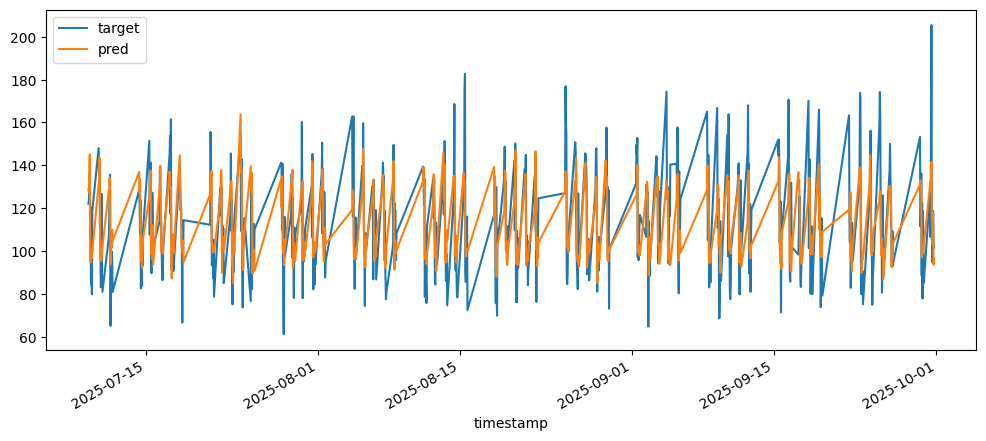

In [48]:
display(xgb_value)
xgb_value.plot(figsize=(12,5))

## DL(RNN)

In [5]:
device = "cuda" if torch.cuda.is_available() else "cpu"

# 단변량 시퀀스 데이터셋 (target만 사용)
class SeqDataset(Dataset):
    def __init__(self, series: np.ndarray, window=24, horizon=1):
        self.window = window
        self.horizon = horizon
        self.X, self.y = [], []
        for i in range(len(series) - window - horizon + 1):
            self.X.append(series[i:i+window])
            self.y.append(series[i+window:i+window+horizon])
        self.X = np.asarray(self.X, dtype=np.float32)
        self.y = np.asarray(self.y, dtype=np.float32).reshape(-1)

    def __len__(self): return len(self.y)
    def __getitem__(self, idx):
        x = self.X[idx][..., None]  # (window, 1)
        y = self.y[idx]
        return torch.from_numpy(x), torch.tensor(y, dtype=torch.float32)

# 표준화(누설 방지: train으로만 fit)
train_target = train_df["target"].values.astype("float32")
test_target  = test_df["target"].values.astype("float32")

mean_t = train_target.mean()
std_t  = train_target.std() + 1e-8
train_t_norm = (train_target - mean_t) / std_t
test_t_norm  = (test_target  - mean_t) / std_t

window = 24
horizon = 1
train_ds = SeqDataset(train_t_norm, window, horizon)
test_ds  = SeqDataset(test_t_norm,  window, horizon)
train_loader = DataLoader(train_ds, batch_size=64, shuffle=True, drop_last=True)
test_loader  = DataLoader(test_ds,  batch_size=64, shuffle=False)

class RNNModel(nn.Module):
    def __init__(self, hidden=64, layers=2, kind="LSTM"):
        super().__init__()
        if kind == "LSTM":
            self.rnn = nn.LSTM(input_size=1, hidden_size=hidden, num_layers=layers, batch_first=True)
        else:
            self.rnn = nn.GRU(input_size=1, hidden_size=hidden, num_layers=layers, batch_first=True)
        self.fc = nn.Linear(hidden, 1)

    def forward(self, x):
        o, _ = self.rnn(x)
        y = self.fc(o[:, -1, :])
        return y.squeeze(1)

def train_rnn(model, loader, epochs=10, lr=1e-3):
    model.to(device)
    opt = torch.optim.Adam(model.parameters(), lr=lr)
    loss_fn = nn.MSELoss()
    model.train()
    for ep in range(epochs):
        for xb, yb in loader:
            xb, yb = xb.to(device), yb.to(device)
            opt.zero_grad()
            pred = model(xb)
            loss = loss_fn(pred, yb)
            loss.backward()
            opt.step()
    return model

# LSTM
lstm = RNNModel(kind="LSTM")
lstm = train_rnn(lstm, train_loader, epochs=12)

# GRU
gru = RNNModel(kind="GRU")
gru = train_rnn(gru, train_loader, epochs=12)

# 테스트 예측 수집
def predict_seq(model, loader) -> np.ndarray:
    model.eval()
    outs = []
    with torch.no_grad():
        for xb, _ in loader:
            xb = xb.to(device)
            pred = model(xb).detach().cpu().numpy()
            outs.append(pred)
    return np.concatenate(outs, axis=0)

pred_lstm_norm = predict_seq(lstm, test_loader)
pred_gru_norm  = predict_seq(gru,  test_loader)

# 역정규화 및 길이 맞추기
pred_lstm = pred_lstm_norm * std_t + mean_t
pred_gru  = pred_gru_norm  * std_t + mean_t

# 테스트 타깃 정렬(윈도우/horizon로 줄어든 길이에 맞춤)
y_test_seq = test_target[window:]

print("LSTM      MAE/RMSE:", metrics(y_test_seq, pred_lstm))
print("GRU       MAE/RMSE:", metrics(y_test_seq, pred_gru))

LSTM      MAE/RMSE: (14.819782, 18.798416)
GRU       MAE/RMSE: (14.576427, 18.644281)


## DL(TFT)

In [16]:
# ===== TFT 전체 교체 블록 (lightning.pytorch로 통일) =====
use_tft = True
tft_pred_series = None
tft_metrics = None

try:
    import numpy as np
    import pandas as pd
    import torch
    import lightning as L  # ★ lightning.pytorch 사용 (PL 대신)

    # PF 1.4.0은 lightning.pytorch.LightningModule을 상속합니다.
    from pytorch_forecasting.models import TemporalFusionTransformer
    from pytorch_forecasting import TimeSeriesDataSet
    from pytorch_forecasting.data import NaNLabelEncoder
    
    torch.set_float32_matmul_precision("high")  # 또는 "medium"
    L.seed_everything(42, workers=True)

    # (0) 정렬 및 dtype 안전화
    df_sorted = df.sort_index()
    req = {"feature1","feature2","target","hour","dayofweek"}
    miss = req - set(df_sorted.columns)
    if miss:
        raise ValueError(f"다음 컬럼이 없습니다: {miss}")

    df_tft = df_sorted.reset_index().rename(columns={"timestamp":"timestamp"})
    if not np.issubdtype(df_tft["timestamp"].dtype, np.datetime64):
        df_tft["timestamp"] = pd.to_datetime(df_tft["timestamp"])

    df_tft["feature1"]  = pd.to_numeric(df_tft["feature1"], errors="coerce").astype("float32")
    df_tft["feature2"]  = pd.to_numeric(df_tft["feature2"], errors="coerce").astype("float32")
    df_tft["target"]    = pd.to_numeric(df_tft["target"],   errors="coerce").astype("float32")
    df_tft["hour"]      = pd.to_numeric(df_tft["hour"],     errors="coerce").astype("int64")
    df_tft["dayofweek"] = pd.to_numeric(df_tft["dayofweek"],errors="coerce").astype("int64")

    # (1) 단일 그룹 + 연속 정수 time_idx (업무시간만 존재 → 달력 불연속 OK)
    df_tft["series"]   = 0
    df_tft["series"]   = df_tft["series"].astype("int64")
    df_tft["time_idx"] = np.arange(len(df_tft), dtype=np.int64)
    df_tft = df_tft.sort_values("time_idx").reset_index(drop=True)

    # (2) 테스트 시작 시점 → time_idx 매핑 (정확 일치 없으면 근사치)
    split_timestamp = test_df.index.min()
    pos = df_tft.index[df_tft["timestamp"] == split_timestamp]
    if len(pos) == 0:
        nearest = int(np.searchsorted(df_tft["timestamp"].values,
                                      np.array(split_timestamp, dtype="datetime64[ns]")))
        nearest = max(0, min(nearest, len(df_tft)-1))
        split_time_idx = int(df_tft.iloc[nearest]["time_idx"])
    else:
        split_time_idx = int(df_tft.loc[pos[0], "time_idx"])

    max_encoder_length = 24
    max_prediction_length = 1

    train_mask = df_tft["time_idx"] < split_time_idx
    valid_mask = df_tft["time_idx"] >= split_time_idx
    if train_mask.sum() < max_encoder_length + max_prediction_length:
        raise ValueError("학습 구간이 너무 짧습니다. split 설정을 확인하세요.")

    # (3) TimeSeriesDataSet (비연속 시간 허용)
    tft_training = TimeSeriesDataSet(
        df_tft.loc[train_mask],
        time_idx="time_idx",
        target="target",
        group_ids=["series"],
        time_varying_unknown_reals=["target"],
        time_varying_known_reals=["hour","dayofweek","feature1","feature2"],
        max_encoder_length=max_encoder_length,
        max_prediction_length=max_prediction_length,
        categorical_encoders={"series": NaNLabelEncoder(add_nan=False)},
        allow_missing_timesteps=True,
    )
    tft_validation = TimeSeriesDataSet.from_dataset(
        tft_training,
        df_tft.loc[valid_mask]
    )

    train_dl = tft_training.to_dataloader(train=True,  batch_size=128, num_workers=0)
    val_dl   = tft_validation.to_dataloader(train=False, batch_size=128, num_workers=0)

    # (4) 모델 구성 (LightningModule)
    tft = TemporalFusionTransformer.from_dataset(
        tft_training,
        learning_rate=1e-3,
        hidden_size=32,
        attention_head_size=1,
        dropout=0.1,
        log_interval=50,
    )

    # (5) 학습: lightning.Trainer 사용 (★ PL.Trainer 아님)
    trainer = L.Trainer(
        max_epochs=5,
        accelerator="gpu" if torch.cuda.is_available() else "cpu",
        devices=1,
        enable_progress_bar=False,
        logger=False,
    )
    trainer.fit(model=tft, train_dataloaders=train_dl, val_dataloaders=val_dl)

    # (6) 예측
    raw_pred = tft.predict(val_dl, return_x=False)  # (N, horizon=1) 텐서/ndarray
    def _to_1d_numpy(x):
        import numpy as _np, torch as _torch
        if isinstance(x, _np.ndarray): arr = x
        elif isinstance(x, _torch.Tensor): arr = x.detach().cpu().numpy()
        elif isinstance(x, (list, tuple)): return _to_1d_numpy(x[0])
        else: arr = _np.asarray(x)
        return arr.reshape(-1)
    tft_pred = _to_1d_numpy(raw_pred)

    y_true_all = df_tft.loc[valid_mask, "target"].values.astype("float32")
    m = min(len(y_true_all), len(tft_pred))
    if m == 0:
        raise ValueError("검증 구간 길이가 0입니다.")
    y_true_tft = y_true_all[:m]
    tft_pred   = tft_pred[:m].astype("float32")

    tft_mae  = float(np.mean(np.abs(y_true_tft - tft_pred)))
    tft_rmse = float(np.sqrt(np.mean((y_true_tft - tft_pred)**2)))
    tft_metrics = (tft_mae, tft_rmse)
    print("TFT       MAE/RMSE:", (tft_mae, tft_rmse))

    # 검증 구간 시간 인덱스
    idx_valid = df_sorted.index[df_sorted.index >= split_timestamp][:m]
    tft_pred_series = pd.Series(tft_pred, index=idx_valid)

except Exception as e:
    use_tft = False
    print("[경고] TFT 스킵:", repr(e))


Seed set to 42
💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
You are using a CUDA device ('NVIDIA RTX A6000') that has Tensor Cores. To properly utilize them, you should set `torch.set_float32_matmul_precision('medium' | 'high')` which will trade-off precision for performance. For more details, read https://pytorch.org/docs/stable/generated/torch.set_float32_matmul_precision.html#torch.set_float32_matmul_precision
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]

   | Name                               | Type                            | Params | Mode 
------------------------------------------------------------------------------------------------
0  | loss                               | QuantileLoss                    | 

TFT       MAE/RMSE: (27.15380859375, 32.049434661865234)


# Result

## prediction

In [17]:
# 각 모델 y_true / y_pred를 공통 DataFrame으로 정리
evals: Dict[str, Tuple[np.ndarray, np.ndarray]] = {}

# Boosting의 y_true
y_true_boost = y_test_b.values
evals["LightGBM"] = (y_true_boost, pred_lgb)
evals["XGBoost"]  = (y_true_boost, pred_xgb)

# LSTM/GRU y_true
evals["LSTM"] = (y_test_seq, pred_lstm)
evals["GRU"]  = (y_test_seq, pred_gru)

# TFT (있으면)
if use_tft and tft_pred_series is not None and tft_metrics is not None:
    # TFT의 y_true는 y_true_tft, 인덱스는 테스트 말미에 정렬
    # 위 셀에서 이미 길이 맞춤
    evals["TFT"] = (y_true_tft, tft_pred)

# 성능 테이블
rows = []
for name, (yt, yp) in evals.items():
    mae, rmse = metrics(yt, yp)
    rows.append((name, mae, rmse))
perf = pd.DataFrame(rows, columns=["model","MAE","RMSE"]).sort_values("RMSE")
print(perf)

best_model_name = perf.iloc[0]["model"]
print(f"\n최적 모델: {best_model_name}")


      model        MAE       RMSE
0  LightGBM  13.950880  17.820252
1   XGBoost  13.979049  17.919899
3       GRU  14.576427  18.644281
2      LSTM  14.819782  18.798416
4       TFT  27.153809  32.049435

최적 모델: LightGBM


## Visualization

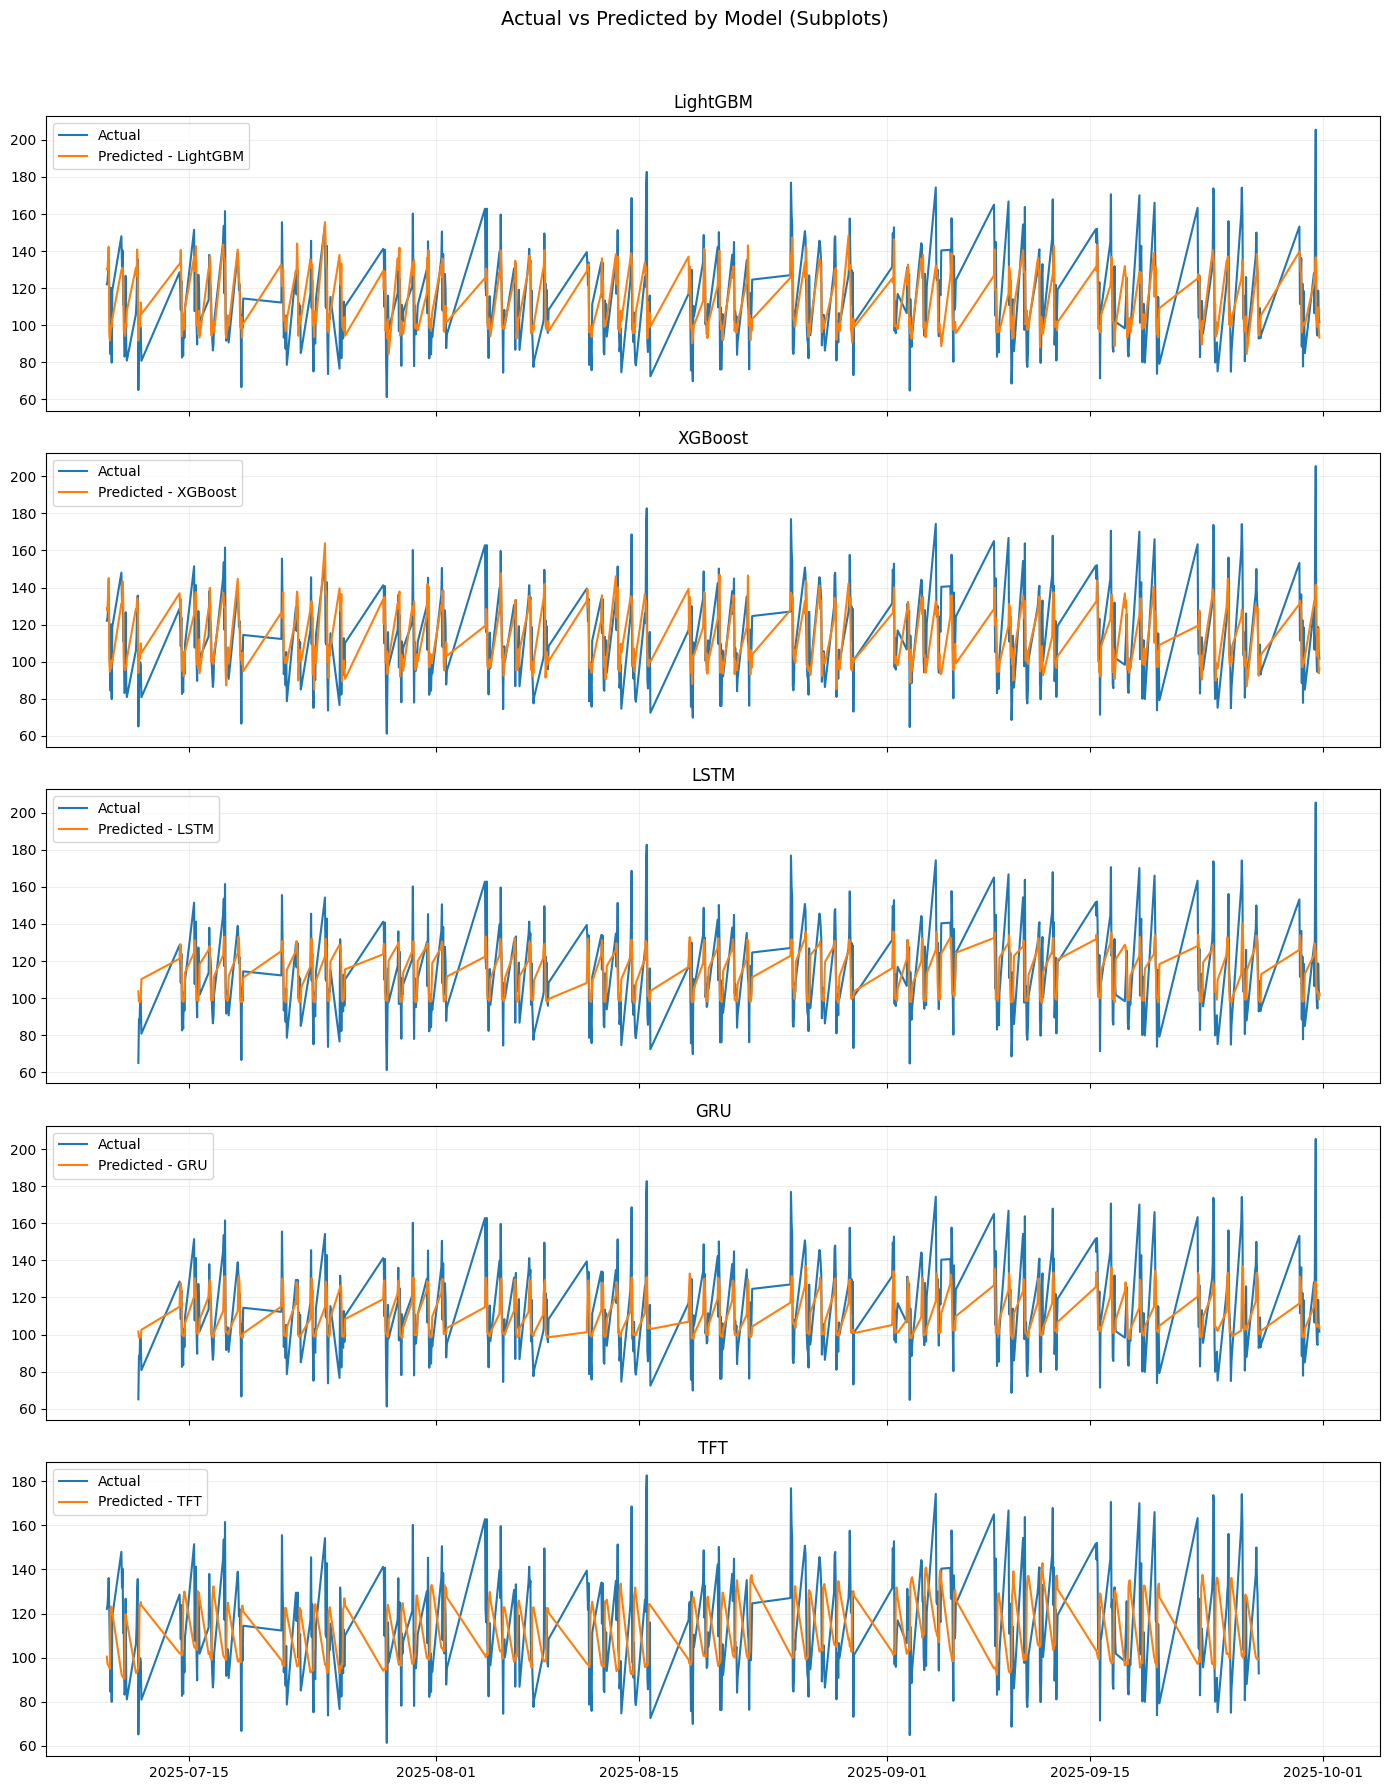

In [18]:
# ===== 모델별 Subplots 시각화 =====
import math

# 1) 모델별 y_true/y_pred와 시간 인덱스 구성
series_list = []  # (title, index, y_true, y_pred)

# Boosting (LightGBM / XGBoost)
series_list.append((
    "LightGBM", y_test_b.index, y_test_b.values, pred_lgb
))
series_list.append((
    "XGBoost",  y_test_b.index, y_test_b.values, pred_xgb
))

# LSTM / GRU (윈도우 만큼 짧아짐)
idx_seq = test_df.index[window:]
series_list.append((
    "LSTM", idx_seq, y_test_seq, pred_lstm
))
series_list.append((
    "GRU",  idx_seq, y_test_seq, pred_gru
))

# TFT (있으면)
if use_tft and (tft_pred_series is not None) and (tft_metrics is not None):
    # TFT의 y_true는 실제 df에서 해당 구간 target
    y_true_tft_aligned = df.loc[tft_pred_series.index, "target"].values
    series_list.append((
        "TFT", tft_pred_series.index, y_true_tft_aligned, tft_pred_series.values
    ))

# 2) 서브플롯 그리기 (한 셀, 여러 플롯)
n = len(series_list)
ncols = 1
nrows = n
fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(14, 3.5*n), sharex=True)

if n == 1:
    axes = [axes]  # 단일 플롯일 때도 리스트처럼 사용

# 최근 테스트 일부만 보고 싶으면 tail_n 조정
tail_n = 600

for ax, (title, idx, y_true, y_pred) in zip(axes, series_list):
    # tail_n 적용
    if len(idx) > tail_n:
        idx = idx[-tail_n:]
        y_true = y_true[-tail_n:]
        y_pred = y_pred[-tail_n:]

    ax.plot(idx, y_true, label="Actual")
    ax.plot(idx, y_pred, label=f"Predicted - {title}")
    ax.set_title(title)
    ax.legend()
    ax.grid(alpha=0.2)

fig.suptitle("Actual vs Predicted by Model (Subplots)", y=1.02, fontsize=14)
plt.tight_layout()
plt.show()


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from dataclasses import dataclass
from typing import Tuple, Dict

# 1) 날짜 인덱스 생성: 2023-01-01 ~ 2025-09-30, 평일만, 09~18시
date_range_full = pd.date_range(start="2023-01-01 00:00", end="2025-09-30 23:00", freq="1h")
date_range = date_range_full[(date_range_full.hour >= 9) & (date_range_full.hour <= 18) & (date_range_full.dayofweek < 5)]

# 2) 기본 feature 생성
N = len(date_range)
feature1 = np.random.normal(50, 10, N)
feature2 = np.random.normal(30,  5, N)

# 3) target 기본값(노이즈 포함)
target_base = np.random.normal(100, 15, N)

# 4) 시즌/시간대 부스트
def seasonal_multiplier(ts):
    year, month, hour = ts.year, ts.month, ts.hour
    mult = 1.0
    # 2023년 10~12월: 붐빔
    if year == 2023 and month in [10, 11, 12]:
        mult *= 1.5
    # 2024년 2분기(4~6월), 4분기(10~12월): 붐빔
    if year == 2024 and month in [4, 5, 6, 10, 11, 12]:
        mult *= 1.7
    # 오전(09~12시) 붐빔
    if 9 <= hour <= 12:
        mult *= 1.3
    return mult

mults = np.array([seasonal_multiplier(ts) for ts in date_range])

# 5) feature를 target과 약간 상관있게(현실감)
#   feature1은 양의 상관, feature2는 약한 음의 상관을 주되, 독립성도 일부 유지
target_trend = target_base * mults
feature1 = feature1 + 0.15 * target_trend / 10.0
feature2 = feature2 - 0.05 * target_trend / 10.0

# 최종 target
target = target_trend

# DataFrame 구성
df = pd.DataFrame(
    {
        "feature1": feature1,
        "feature2": feature2,
        "target":   target,
    },
    index=pd.DatetimeIndex(date_range, name="timestamp")
)

# 편의 feature
df["hour"] = df.index.hour
df["dayofweek"] = df.index.dayofweek

print(df.head(3), "\n...", "\n", df.tail(3))
print("총 샘플 수:", len(df))

# 전처리

# 시간지연/롤링 특징 (누설 방지)
def add_time_features(frame: pd.DataFrame, target_col="target") -> pd.DataFrame:
    out = frame.copy()
    # Lags
    for lag in [1, 2, 3, 24]:  # 바로 전, 2,3시간 전 + 하루 전(업무시간 기준)
        out[f"{target_col}_lag{lag}"] = out[target_col].shift(lag)
    # Rolling means (최근 흐름)
    for w in [3, 6]:
        out[f"{target_col}_rmean{w}"] = out[target_col].shift(1).rolling(w).mean()
    return out

df_b = add_time_features(df)

# 결측(초기 lag/rolling) 제거
df_b = df_b.dropna().copy()

# 시간기반 분할: 최근 60 영업일을 테스트로 (필요 시 조정)
# 영업일 기준 1일 10샘플(09~18시) → 약 600 샘플
test_days = 60
hours_per_day = 10
test_len = test_days * hours_per_day
train_df = df_b.iloc[:-test_len]
test_df  = df_b.iloc[-test_len:]

# Boosting 입력/타깃
boost_cols = [
    "feature1","feature2","hour","dayofweek",
    "target_lag1","target_lag2","target_lag3","target_lag24",
    "target_rmean3","target_rmean6",
]
X_train_b, y_train_b = train_df[boost_cols], train_df["target"]
X_test_b,  y_test_b  = test_df[boost_cols],  test_df["target"]

print("Train:", X_train_b.shape, "Test:", X_test_b.shape)

# 모델링

## ML(Boost)

from sklearn.metrics import mean_absolute_error, mean_squared_error
import warnings
try:
    import lightgbm as lgb
    lgbm = lgb.LGBMRegressor(
        n_estimators=600,
        learning_rate=0.05,
        subsample=0.9,
        colsample_bytree=0.8,
        random_state=42,
        # GPU 사용 가능 시:
        device="gpu"
    )
except Exception:
    # CPU fallback
    import lightgbm as lgb
    lgbm = lgb.LGBMRegressor(
        n_estimators=600,
        learning_rate=0.05,
        subsample=0.9,
        colsample_bytree=0.8,
        random_state=42,
    )

lgbm.fit(X_train_b, y_train_b)
pred_lgb = lgbm.predict(X_test_b)

# XGBoost
import xgboost as xgb
xgbm = xgb.XGBRegressor(
    n_estimators=800,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.9,
    colsample_bytree=0.8,
    random_state=42,
    tree_method="gpu_hist",        # GPU
    predictor="gpu_predictor"
)
try:
    xgbm.fit(X_train_b, y_train_b, eval_set=[(X_test_b, y_test_b)], verbose=False)
except Exception:
    # CPU fallback
    xgbm = xgb.XGBRegressor(
        n_estimators=800,
        learning_rate=0.05,
        max_depth=6,
        subsample=0.9,
        colsample_bytree=0.8,
        random_state=42,
        tree_method="hist"
    )
    xgbm.fit(X_train_b, y_train_b, eval_set=[(X_test_b, y_test_b)], verbose=False)

pred_xgb = xgbm.predict(X_test_b)

def metrics(y_true, y_pred) -> Tuple[float, float]:
    mae = mean_absolute_error(y_true, y_pred)
    rmse = mean_squared_error(y_true, y_pred, squared=False)
    return mae, rmse

print("LightGBM  MAE/RMSE:", metrics(y_test_b, pred_lgb))
print("XGBoost   MAE/RMSE:", metrics(y_test_b, pred_xgb))

## DL(RNN)

device = "cuda" if torch.cuda.is_available() else "cpu"

# 단변량 시퀀스 데이터셋 (target만 사용)
class SeqDataset(Dataset):
    def __init__(self, series: np.ndarray, window=24, horizon=1):
        self.window = window
        self.horizon = horizon
        self.X, self.y = [], []
        for i in range(len(series) - window - horizon + 1):
            self.X.append(series[i:i+window])
            self.y.append(series[i+window:i+window+horizon])
        self.X = np.asarray(self.X, dtype=np.float32)
        self.y = np.asarray(self.y, dtype=np.float32).reshape(-1)

    def __len__(self): return len(self.y)
    def __getitem__(self, idx):
        x = self.X[idx][..., None]  # (window, 1)
        y = self.y[idx]
        return torch.from_numpy(x), torch.tensor(y, dtype=torch.float32)

# 표준화(누설 방지: train으로만 fit)
train_target = train_df["target"].values.astype("float32")
test_target  = test_df["target"].values.astype("float32")

mean_t = train_target.mean()
std_t  = train_target.std() + 1e-8
train_t_norm = (train_target - mean_t) / std_t
test_t_norm  = (test_target  - mean_t) / std_t

window = 24
horizon = 1
train_ds = SeqDataset(train_t_norm, window, horizon)
test_ds  = SeqDataset(test_t_norm,  window, horizon)
train_loader = DataLoader(train_ds, batch_size=64, shuffle=True, drop_last=True)
test_loader  = DataLoader(test_ds,  batch_size=64, shuffle=False)

class RNNModel(nn.Module):
    def __init__(self, hidden=64, layers=2, kind="LSTM"):
        super().__init__()
        if kind == "LSTM":
            self.rnn = nn.LSTM(input_size=1, hidden_size=hidden, num_layers=layers, batch_first=True)
        else:
            self.rnn = nn.GRU(input_size=1, hidden_size=hidden, num_layers=layers, batch_first=True)
        self.fc = nn.Linear(hidden, 1)

    def forward(self, x):
        o, _ = self.rnn(x)
        y = self.fc(o[:, -1, :])
        return y.squeeze(1)

def train_rnn(model, loader, epochs=10, lr=1e-3):
    model.to(device)
    opt = torch.optim.Adam(model.parameters(), lr=lr)
    loss_fn = nn.MSELoss()
    model.train()
    for ep in range(epochs):
        for xb, yb in loader:
            xb, yb = xb.to(device), yb.to(device)
            opt.zero_grad()
            pred = model(xb)
            loss = loss_fn(pred, yb)
            loss.backward()
            opt.step()
    return model

# LSTM
lstm = RNNModel(kind="LSTM")
lstm = train_rnn(lstm, train_loader, epochs=12)

# GRU
gru = RNNModel(kind="GRU")
gru = train_rnn(gru, train_loader, epochs=12)

# 테스트 예측 수집
def predict_seq(model, loader) -> np.ndarray:
    model.eval()
    outs = []
    with torch.no_grad():
        for xb, _ in loader:
            xb = xb.to(device)
            pred = model(xb).detach().cpu().numpy()
            outs.append(pred)
    return np.concatenate(outs, axis=0)

pred_lstm_norm = predict_seq(lstm, test_loader)
pred_gru_norm  = predict_seq(gru,  test_loader)

# 역정규화 및 길이 맞추기
pred_lstm = pred_lstm_norm * std_t + mean_t
pred_gru  = pred_gru_norm  * std_t + mean_t

# 테스트 타깃 정렬(윈도우/horizon로 줄어든 길이에 맞춤)
y_test_seq = test_target[window:]

print("LSTM      MAE/RMSE:", metrics(y_test_seq, pred_lstm))
print("GRU       MAE/RMSE:", metrics(y_test_seq, pred_gru))

## DL(TFT)

# ===== TFT 전체 교체 블록 (lightning.pytorch로 통일) =====
use_tft = True
tft_pred_series = None
tft_metrics = None

try:
    import numpy as np
    import pandas as pd
    import torch
    import lightning as L  # ★ lightning.pytorch 사용 (PL 대신)

    # PF 1.4.0은 lightning.pytorch.LightningModule을 상속합니다.
    from pytorch_forecasting.models import TemporalFusionTransformer
    from pytorch_forecasting import TimeSeriesDataSet
    from pytorch_forecasting.data import NaNLabelEncoder
    
    torch.set_float32_matmul_precision("high")  # 또는 "medium"
    L.seed_everything(42, workers=True)

    # (0) 정렬 및 dtype 안전화
    df_sorted = df.sort_index()
    req = {"feature1","feature2","target","hour","dayofweek"}
    miss = req - set(df_sorted.columns)
    if miss:
        raise ValueError(f"다음 컬럼이 없습니다: {miss}")

    df_tft = df_sorted.reset_index().rename(columns={"timestamp":"timestamp"})
    if not np.issubdtype(df_tft["timestamp"].dtype, np.datetime64):
        df_tft["timestamp"] = pd.to_datetime(df_tft["timestamp"])

    df_tft["feature1"]  = pd.to_numeric(df_tft["feature1"], errors="coerce").astype("float32")
    df_tft["feature2"]  = pd.to_numeric(df_tft["feature2"], errors="coerce").astype("float32")
    df_tft["target"]    = pd.to_numeric(df_tft["target"],   errors="coerce").astype("float32")
    df_tft["hour"]      = pd.to_numeric(df_tft["hour"],     errors="coerce").astype("int64")
    df_tft["dayofweek"] = pd.to_numeric(df_tft["dayofweek"],errors="coerce").astype("int64")

    # (1) 단일 그룹 + 연속 정수 time_idx (업무시간만 존재 → 달력 불연속 OK)
    df_tft["series"]   = 0
    df_tft["series"]   = df_tft["series"].astype("int64")
    df_tft["time_idx"] = np.arange(len(df_tft), dtype=np.int64)
    df_tft = df_tft.sort_values("time_idx").reset_index(drop=True)

    # (2) 테스트 시작 시점 → time_idx 매핑 (정확 일치 없으면 근사치)
    split_timestamp = test_df.index.min()
    pos = df_tft.index[df_tft["timestamp"] == split_timestamp]
    if len(pos) == 0:
        nearest = int(np.searchsorted(df_tft["timestamp"].values,
                                      np.array(split_timestamp, dtype="datetime64[ns]")))
        nearest = max(0, min(nearest, len(df_tft)-1))
        split_time_idx = int(df_tft.iloc[nearest]["time_idx"])
    else:
        split_time_idx = int(df_tft.loc[pos[0], "time_idx"])

    max_encoder_length = 24
    max_prediction_length = 1

    train_mask = df_tft["time_idx"] < split_time_idx
    valid_mask = df_tft["time_idx"] >= split_time_idx
    if train_mask.sum() < max_encoder_length + max_prediction_length:
        raise ValueError("학습 구간이 너무 짧습니다. split 설정을 확인하세요.")

    # (3) TimeSeriesDataSet (비연속 시간 허용)
    tft_training = TimeSeriesDataSet(
        df_tft.loc[train_mask],
        time_idx="time_idx",
        target="target",
        group_ids=["series"],
        time_varying_unknown_reals=["target"],
        time_varying_known_reals=["hour","dayofweek","feature1","feature2"],
        max_encoder_length=max_encoder_length,
        max_prediction_length=max_prediction_length,
        categorical_encoders={"series": NaNLabelEncoder(add_nan=False)},
        allow_missing_timesteps=True,
    )
    tft_validation = TimeSeriesDataSet.from_dataset(
        tft_training,
        df_tft.loc[valid_mask]
    )

    train_dl = tft_training.to_dataloader(train=True,  batch_size=128, num_workers=0)
    val_dl   = tft_validation.to_dataloader(train=False, batch_size=128, num_workers=0)

    # (4) 모델 구성 (LightningModule)
    tft = TemporalFusionTransformer.from_dataset(
        tft_training,
        learning_rate=1e-3,
        hidden_size=32,
        attention_head_size=1,
        dropout=0.1,
        log_interval=50,
    )

    # (5) 학습: lightning.Trainer 사용 (★ PL.Trainer 아님)
    trainer = L.Trainer(
        max_epochs=5,
        accelerator="gpu" if torch.cuda.is_available() else "cpu",
        devices=1,
        enable_progress_bar=False,
        logger=False,
    )
    trainer.fit(model=tft, train_dataloaders=train_dl, val_dataloaders=val_dl)

    # (6) 예측
    raw_pred = tft.predict(val_dl, return_x=False)  # (N, horizon=1) 텐서/ndarray
    def _to_1d_numpy(x):
        import numpy as _np, torch as _torch
        if isinstance(x, _np.ndarray): arr = x
        elif isinstance(x, _torch.Tensor): arr = x.detach().cpu().numpy()
        elif isinstance(x, (list, tuple)): return _to_1d_numpy(x[0])
        else: arr = _np.asarray(x)
        return arr.reshape(-1)
    tft_pred = _to_1d_numpy(raw_pred)

    y_true_all = df_tft.loc[valid_mask, "target"].values.astype("float32")
    m = min(len(y_true_all), len(tft_pred))
    if m == 0:
        raise ValueError("검증 구간 길이가 0입니다.")
    y_true_tft = y_true_all[:m]
    tft_pred   = tft_pred[:m].astype("float32")

    tft_mae  = float(np.mean(np.abs(y_true_tft - tft_pred)))
    tft_rmse = float(np.sqrt(np.mean((y_true_tft - tft_pred)**2)))
    tft_metrics = (tft_mae, tft_rmse)
    print("TFT       MAE/RMSE:", (tft_mae, tft_rmse))

    # 검증 구간 시간 인덱스
    idx_valid = df_sorted.index[df_sorted.index >= split_timestamp][:m]
    tft_pred_series = pd.Series(tft_pred, index=idx_valid)

except Exception as e:
    use_tft = False
    print("[경고] TFT 스킵:", repr(e))


# Result

## prediction

# 각 모델 y_true / y_pred를 공통 DataFrame으로 정리
evals: Dict[str, Tuple[np.ndarray, np.ndarray]] = {}

# Boosting의 y_true
y_true_boost = y_test_b.values
evals["LightGBM"] = (y_true_boost, pred_lgb)
evals["XGBoost"]  = (y_true_boost, pred_xgb)

# LSTM/GRU y_true
evals["LSTM"] = (y_test_seq, pred_lstm)
evals["GRU"]  = (y_test_seq, pred_gru)

# TFT (있으면)
if use_tft and tft_pred_series is not None and tft_metrics is not None:
    # TFT의 y_true는 y_true_tft, 인덱스는 테스트 말미에 정렬
    # 위 셀에서 이미 길이 맞춤
    evals["TFT"] = (y_true_tft, tft_pred)

# 성능 테이블
rows = []
for name, (yt, yp) in evals.items():
    mae, rmse = metrics(yt, yp)
    rows.append((name, mae, rmse))
perf = pd.DataFrame(rows, columns=["model","MAE","RMSE"]).sort_values("RMSE")
print(perf)

best_model_name = perf.iloc[0]["model"]
print(f"\n최적 모델: {best_model_name}")


## Visualization

# ===== 모델별 Subplots 시각화 =====
import math

# 1) 모델별 y_true/y_pred와 시간 인덱스 구성
series_list = []  # (title, index, y_true, y_pred)

# Boosting (LightGBM / XGBoost)
series_list.append((
    "LightGBM", y_test_b.index, y_test_b.values, pred_lgb
))
series_list.append((
    "XGBoost",  y_test_b.index, y_test_b.values, pred_xgb
))

# LSTM / GRU (윈도우 만큼 짧아짐)
idx_seq = test_df.index[window:]
series_list.append((
    "LSTM", idx_seq, y_test_seq, pred_lstm
))
series_list.append((
    "GRU",  idx_seq, y_test_seq, pred_gru
))

# TFT (있으면)
if use_tft and (tft_pred_series is not None) and (tft_metrics is not None):
    # TFT의 y_true는 실제 df에서 해당 구간 target
    y_true_tft_aligned = df.loc[tft_pred_series.index, "target"].values
    series_list.append((
        "TFT", tft_pred_series.index, y_true_tft_aligned, tft_pred_series.values
    ))

# 2) 서브플롯 그리기 (한 셀, 여러 플롯)
n = len(series_list)
ncols = 1
nrows = n
fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(14, 3.5*n), sharex=True)

if n == 1:
    axes = [axes]  # 단일 플롯일 때도 리스트처럼 사용

# 최근 테스트 일부만 보고 싶으면 tail_n 조정
tail_n = 600

for ax, (title, idx, y_true, y_pred) in zip(axes, series_list):
    # tail_n 적용
    if len(idx) > tail_n:
        idx = idx[-tail_n:]
        y_true = y_true[-tail_n:]
        y_pred = y_pred[-tail_n:]

    ax.plot(idx, y_true, label="Actual")
    ax.plot(idx, y_pred, label=f"Predicted - {title}")
    ax.set_title(title)
    ax.legend()
    ax.grid(alpha=0.2)

fig.suptitle("Actual vs Predicted by Model (Subplots)", y=1.02, fontsize=14)
plt.tight_layout()
plt.show()


# Perf improve comparison

In [19]:
# === 셀 A: 공통 유틸 + 베이스라인 성능표 ===
import numpy as np, pandas as pd, warnings, torch
from sklearn.metrics import mean_absolute_error, mean_squared_error
warnings.filterwarnings("ignore")

def set_matmul_precision(level="high"):
    try:
        torch.set_float32_matmul_precision(level)
    except Exception:
        pass

def metrics_all(y_true, y_pred):
    y_true = np.asarray(y_true); y_pred = np.asarray(y_pred)
    mae  = mean_absolute_error(y_true, y_pred)
    rmse = mean_squared_error(y_true, y_pred, squared=False)
    mape = float(np.mean(np.abs((y_true - y_pred) / np.maximum(1e-8, np.abs(y_true)))) * 100.0)
    return {"MAE":mae, "RMSE":rmse, "MAPE(%)":mape}

def perf_table(rows):
    dfp = pd.DataFrame(rows, columns=["Model","MAE","RMSE","MAPE(%)"])
    return dfp.sort_values("RMSE").reset_index(drop=True)

# ---- 베이스라인 성능 (사용자 코드 결과를 그대로 표로) ----
rows_before = []
rows_before.append(("LightGBM(base)", *metrics_all(y_test_b.values, pred_lgb).values()))
rows_before.append(("XGBoost(base)",  *metrics_all(y_test_b.values, pred_xgb).values()))

# LSTM/GRU는 사용자 코드 기준 변수 사용
rows_before.append(("LSTM(base)", *metrics_all(y_test_seq, pred_lstm).values()))
rows_before.append(("GRU(base)",  *metrics_all(y_test_seq, pred_gru).values()))

# TFT가 이미 성공했다면 포함
try:
    if (use_tft is True) and (tft_pred_series is not None):
        y_true_tft_base = df.loc[tft_pred_series.index, "target"].values
        rows_before.append(("TFT(base)", *metrics_all(y_true_tft_base, tft_pred_series.values).values()))
except NameError:
    pass

perf_before = perf_table(rows_before)
display(perf_before.style.set_caption("Baseline Performance (before tuning)"))


,Model,MAE,RMSE,MAPE(%)
0,LightGBM(base),13.950880,17.820252,12.894809
1,XGBoost(base),13.979049,17.919899,12.901087
2,GRU(base),14.576427,18.644281,13.198037
3,LSTM(base),14.819782,18.798416,13.540313
4,TFT(base),27.153809,32.049433,24.628377


# Boost Tuning > Test Validation

In [20]:
# === 셀 B: LightGBM/XGBoost 튜닝 (Optuna) → 테스트셋 평가 ===
# !pip install -q optuna
import optuna
from optuna.pruners import MedianPruner

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
HOURS_PER_DAY = 10
VAL_DAYS_INNER = 20
VAL_LEN_INNER  = VAL_DAYS_INNER * HOURS_PER_DAY

def rmse(a, b):
    return float(mean_squared_error(a, b, squared=False))

# ---- LightGBM ----
def tune_lightgbm(X_train_full, y_train_full, trials=20):
    import lightgbm as lgb
    X_tr, y_tr = X_train_full.iloc[:-VAL_LEN_INNER], y_train_full.iloc[:-VAL_LEN_INNER]
    X_val, y_val = X_train_full.iloc[-VAL_LEN_INNER:], y_train_full.iloc[-VAL_LEN_INNER:]

    def objective(trial):
        params = dict(
            n_estimators = trial.suggest_int("n_estimators", 300, 1500, step=100),
            learning_rate= trial.suggest_float("learning_rate", 1e-3, 0.2, log=True),
            num_leaves   = trial.suggest_int("num_leaves", 31, 255),
            max_depth    = trial.suggest_int("max_depth", 3, 12),
            min_child_samples = trial.suggest_int("min_child_samples", 5, 100),
            subsample    = trial.suggest_float("subsample", 0.6, 1.0),
            colsample_bytree = trial.suggest_float("colsample_bytree", 0.6, 1.0),
            reg_alpha    = trial.suggest_float("reg_alpha", 0.0, 5.0),
            reg_lambda   = trial.suggest_float("reg_lambda", 0.0, 5.0),
            random_state = 42,
        )
        try:
            model = lgb.LGBMRegressor(device="gpu", **params)
        except TypeError:
            model = lgb.LGBMRegressor(**params)

        model.fit(
            X_tr, y_tr,
            eval_set=[(X_val, y_val)],
            eval_metric="rmse",
            callbacks=[lgb.early_stopping(100, verbose=False)]
        )
        pred = model.predict(X_val)
        return rmse(y_val, pred)

    study = optuna.create_study(direction="minimize", pruner=MedianPruner())
    study.optimize(objective, n_trials=trials, show_progress_bar=False)
    best_params = study.best_params

    # 재학습 → test
    try:
        best_model = lgb.LGBMRegressor(device="gpu", **best_params)
    except TypeError:
        best_model = lgb.LGBMRegressor(**best_params)
    best_model.fit(X_train_full, y_train_full)
    pred_test = best_model.predict(X_test_b)
    return best_model, pred_test, best_params

# ---- XGBoost ----
def tune_xgboost(X_train_full, y_train_full, trials=20):
    import xgboost as xgb
    X_tr, y_tr = X_train_full.iloc[:-VAL_LEN_INNER], y_train_full.iloc[:-VAL_LEN_INNER]
    X_val, y_val = X_train_full.iloc[-VAL_LEN_INNER:], y_train_full.iloc[-VAL_LEN_INNER:]

    dtr = xgb.DMatrix(X_tr, label=y_tr)
    dval = xgb.DMatrix(X_val, label=y_val)

    def objective(trial):
        params = {
            "objective": "reg:squarederror",
            "eval_metric": "rmse",
            "tree_method": "gpu_hist",
            "predictor": "gpu_predictor",
            "eta": trial.suggest_float("eta", 1e-3, 0.2, log=True),
            "max_depth": trial.suggest_int("max_depth", 3, 12),
            "min_child_weight": trial.suggest_float("min_child_weight", 1.0, 20.0),
            "subsample": trial.suggest_float("subsample", 0.6, 1.0),
            "colsample_bytree": trial.suggest_float("colsample_bytree", 0.6, 1.0),
            "lambda": trial.suggest_float("lambda", 0.0, 5.0),
            "alpha": trial.suggest_float("alpha", 0.0, 5.0),
        }
        num_boost = trial.suggest_int("n_estimators", 300, 2000, step=100)
        booster = xgb.train(
            params, dtr, num_boost_round=num_boost,
            evals=[(dval, "val")],
            early_stopping_rounds=200, verbose_eval=False
        )
        pred = booster.predict(dval)
        return rmse(y_val, pred)

    study = optuna.create_study(direction="minimize", pruner=MedianPruner())
    study.optimize(objective, n_trials=trials, show_progress_bar=False)
    best_params = study.best_params

    # 재학습 → test
    import xgboost as xgb
    dtrain_full = xgb.DMatrix(X_train_full, label=y_train_full)
    dtest = xgb.DMatrix(X_test_b)
    booster = xgb.train(
        {
            "objective": "reg:squarederror",
            "eval_metric": "rmse",
            "tree_method": "gpu_hist",
            "predictor": "gpu_predictor",
            "eta": best_params["eta"],
            "max_depth": best_params["max_depth"],
            "min_child_weight": best_params["min_child_weight"],
            "subsample": best_params["subsample"],
            "colsample_bytree": best_params["colsample_bytree"],
            "lambda": best_params["lambda"],
            "alpha": best_params["alpha"],
        },
        dtrain_full, num_boost_round=best_params["n_estimators"]
    )
    pred_test = booster.predict(dtest)
    return booster, pred_test, best_params

# 실행
best_lgb, pred_lgb_tuned, best_params_lgb = tune_lightgbm(X_train_b, y_train_b, trials=20)
best_xgb, pred_xgb_tuned, best_params_xgb = tune_xgboost(X_train_b, y_train_b, trials=20)

print("[LGBM best]", best_params_lgb)
print("[XGB  best]", best_params_xgb)


[I 2025-09-03 16:23:36,726] A new study created in memory with name: no-name-1136eb73-5eaa-4148-b01d-8aa07d3c545a


[LightGBM] [Info] This is the GPU trainer!!
[LightGBM] [Info] Total Bins 2056
[LightGBM] [Info] Number of data points in the train set: 6346, number of used features: 10
[LightGBM] [Info] Using GPU Device: NVIDIA RTX A6000, Vendor: NVIDIA Corporation
[LightGBM] [Info] Compiling OpenCL Kernel with 256 bins...
[LightGBM] [Info] GPU programs have been built
[LightGBM] [Info] Size of histogram bin entry: 8
[LightGBM] [Info] 10 dense feature groups (0.07 MB) transferred to GPU in 0.000358 secs. 0 sparse feature groups
[LightGBM] [Info] Start training from score 134.218710
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positiv

[I 2025-09-03 16:23:37,047] Trial 0 finished with value: 16.655612861447544 and parameters: {'n_estimators': 1200, 'learning_rate': 0.01867185151728012, 'num_leaves': 129, 'max_depth': 4, 'min_child_samples': 19, 'subsample': 0.8058664030078133, 'colsample_bytree': 0.7466193203358715, 'reg_alpha': 0.6912153858972325, 'reg_lambda': 0.562549033888704}. Best is trial 0 with value: 16.655612861447544.


[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No f

[I 2025-09-03 16:23:37,550] Trial 1 finished with value: 16.674479047152815 and parameters: {'n_estimators': 300, 'learning_rate': 0.0070853578485365705, 'num_leaves': 182, 'max_depth': 8, 'min_child_samples': 65, 'subsample': 0.6920486313413458, 'colsample_bytree': 0.979262803998179, 'reg_alpha': 2.3520249277872782, 'reg_lambda': 3.556950518838198}. Best is trial 0 with value: 16.655612861447544.


...

[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No f

[I 2025-09-03 16:23:54,376] Trial 19 finished with value: 17.221401781672117 and parameters: {'n_estimators': 1000, 'learning_rate': 0.035489382038243984, 'num_leaves': 255, 'max_depth': 12, 'min_child_samples': 9, 'subsample': 0.6005449081607274, 'colsample_bytree': 0.775802700894625, 'reg_alpha': 1.6736268285347673, 'reg_lambda': 1.2969598386821397}. Best is trial 18 with value: 16.307481597703184.


[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No f

[I 2025-09-03 16:23:56,997] A new study created in memory with name: no-name-0b96d306-e79f-4b0f-9af5-88e6e4e22a0f
[I 2025-09-03 16:23:57,478] Trial 0 finished with value: 17.19254461331094 and parameters: {'eta': 0.040231552827032405, 'max_depth': 7, 'min_child_weight': 5.821667053299018, 'subsample': 0.8375256294298676, 'colsample_bytree': 0.7437520924526315, 'lambda': 1.8981178732390087, 'alpha': 2.6118159651304036, 'n_estimators': 1800}. Best is trial 0 with value: 17.19254461331094.
[I 2025-09-03 16:23:57,692] Trial 1 finished with value: 16.783022981555526 and parameters: {'eta': 0.09231392954616757, 'max_depth': 4, 'min_child_weight': 2.995707018329278, 'subsample': 0.9361699348381994, 'colsample_bytree': 0.7462658628273903, 'lambda': 3.556791230621315, 'alpha': 2.1457656015826707, 'n_estimators': 1700}. Best is trial 1 with value: 16.783022981555526.
[I 2025-09-03 16:23:58,124] Trial 2 finished with value: 17.224484706068207 and parameters: {'eta': 0.05449243648710513, 'max_dept

[LGBM best] {'n_estimators': 1100, 'learning_rate': 0.04965050481768321, 'num_leaves': 169, 'max_depth': 8, 'min_child_samples': 6, 'subsample': 0.6002633572091568, 'colsample_bytree': 0.999363480310086, 'reg_alpha': 1.8050854870001496, 'reg_lambda': 1.612047296588353}
[XGB  best] {'eta': 0.004163584376068261, 'max_depth': 5, 'min_child_weight': 1.8179597801201441, 'subsample': 0.7216080132242411, 'colsample_bytree': 0.9022732458848894, 'lambda': 2.5556501235222586, 'alpha': 4.0220071591029045, 'n_estimators': 1400}


In [21]:
# === 셀 C: LSTM/GRU 튜닝 (Optuna) → 테스트셋 평가 ===
import torch, torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import optuna
from optuna.pruners import MedianPruner

set_matmul_precision("high")
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

class SeqDataset(Dataset):
    def __init__(self, series: np.ndarray, window=24, horizon=1):
        X, y = [], []
        for i in range(len(series) - window - horizon + 1):
            X.append(series[i:i+window]); y.append(series[i+window:i+window+horizon])
        self.X = torch.tensor(np.array(X, dtype=np.float32)[:, :, None])
        self.y = torch.tensor(np.array(y, dtype=np.float32).reshape(-1))
    def __len__(self): return len(self.y)
    def __getitem__(self, i): return self.X[i], self.y[i]

class RNNModel(nn.Module):
    def __init__(self, hidden=64, layers=2, kind="LSTM"):
        super().__init__()
        rnn_cls = nn.LSTM if kind=="LSTM" else nn.GRU
        self.rnn = rnn_cls(input_size=1, hidden_size=hidden, num_layers=layers, batch_first=True)
        self.fc  = nn.Linear(hidden, 1)
    def forward(self, x):
        o, _ = self.rnn(x); return self.fc(o[:, -1, :]).squeeze(1)

def _norm(arr, mean=None, std=None):
    if mean is None: mean = arr.mean()
    if std  is None: std  = arr.std() + 1e-8
    return (arr-mean)/std, mean, std

def tune_rnn(kind="LSTM", trials=15):
    tr = train_df["target"].values.astype("float32")
    tr_n, mu, sd = _norm(tr)
    val_points = VAL_LEN_INNER
    tr_train, tr_val = tr_n[:-val_points], tr_n[-val_points:]

    def objective(trial):
        window = trial.suggest_categorical("window", [12, 24, 36, 48])
        hidden = trial.suggest_categorical("hidden", [32, 64, 96, 128])
        layers = trial.suggest_int("layers", 1, 3)
        lr     = trial.suggest_float("lr", 1e-4, 5e-3, log=True)
        epochs = trial.suggest_int("epochs", 6, 20)
        bsz    = trial.suggest_categorical("batch_size", [64, 128, 256])

        ds_tr  = SeqDataset(tr_train, window=window); dl_tr = DataLoader(ds_tr, batch_size=bsz, shuffle=True, drop_last=True)
        ds_val = SeqDataset(tr_val,   window=window); dl_va = DataLoader(ds_val, batch_size=bsz*2, shuffle=False)

        model = RNNModel(hidden=hidden, layers=layers, kind=kind).to(DEVICE)
        opt   = torch.optim.Adam(model.parameters(), lr=lr)
        loss_fn = nn.MSELoss()

        best = 1e9; patience, wait = 3, 0
        for ep in range(epochs):
            model.train()
            for xb, yb in dl_tr:
                xb, yb = xb.to(DEVICE), yb.to(DEVICE)
                opt.zero_grad(); pred = model(xb); loss = loss_fn(pred, yb); loss.backward(); opt.step()
            # val
            model.eval(); preds=[]
            with torch.no_grad():
                for xb, _ in dl_va:
                    preds.append(model(xb.to(DEVICE)).detach().cpu())
            y_pred = torch.cat(preds).numpy() * sd + mu
            y_true = train_df["target"].values[-val_points:][window:].astype("float32")
            score = rmse(y_true, y_pred)
            if score < best: best = score; wait = 0
            else:
                wait += 1
                if wait >= patience: break
        return best

    study = optuna.create_study(direction="minimize", pruner=MedianPruner())
    study.optimize(objective, n_trials=trials, show_progress_bar=False)
    bp = study.best_params

    # 전체 train 재학습 → test 예측
    all_tr = train_df["target"].values.astype("float32")
    all_n, mu, sd = _norm(all_tr)
    ds_all  = SeqDataset(all_n, window=bp["window"])
    ds_test = SeqDataset((test_df["target"].values.astype("float32")-mu)/sd, window=bp["window"])
    dl_all  = DataLoader(ds_all,  batch_size=bp["batch_size"], shuffle=True, drop_last=True)
    dl_test = DataLoader(ds_test, batch_size=bp["batch_size"]*2, shuffle=False)

    model = RNNModel(hidden=bp["hidden"], layers=bp["layers"], kind=kind).to(DEVICE)
    opt   = torch.optim.Adam(model.parameters(), lr=bp["lr"])
    loss_fn = nn.MSELoss()
    for ep in range(bp["epochs"]):
        model.train()
        for xb, yb in dl_all:
            xb, yb = xb.to(DEVICE), yb.to(DEVICE)
            opt.zero_grad(); pred = model(xb); loss = loss_fn(pred, yb); loss.backward(); opt.step()

    # test 예측
    model.eval(); preds=[]
    with torch.no_grad():
        for xb, _ in dl_test:
            preds.append(model(xb.to(DEVICE)).detach().cpu())
    pred = torch.cat(preds).numpy() * sd + mu
    y_true_seq = test_df["target"].values[bp["window"]:]
    return model, pred, y_true_seq, bp

lstm_best, pred_lstm_tuned, y_test_seq_lstm, best_params_lstm = tune_rnn("LSTM", trials=15)
gru_best,  pred_gru_tuned,  y_test_seq_gru,  best_params_gru  = tune_rnn("GRU",  trials=15)

print("[LSTM best]", best_params_lstm)
print("[GRU  best]", best_params_gru)


[I 2025-09-03 16:25:11,162] A new study created in memory with name: no-name-089fd6e6-83c7-4866-8a39-890b5bb436ef
[I 2025-09-03 16:25:11,814] Trial 0 finished with value: 16.579631805419922 and parameters: {'window': 48, 'hidden': 32, 'layers': 2, 'lr': 0.0022092058476957856, 'epochs': 7, 'batch_size': 64}. Best is trial 0 with value: 16.579631805419922.
[I 2025-09-03 16:25:12,227] Trial 1 finished with value: 21.222562789916992 and parameters: {'window': 12, 'hidden': 64, 'layers': 1, 'lr': 0.00026416479196512174, 'epochs': 14, 'batch_size': 256}. Best is trial 0 with value: 16.579631805419922.
[I 2025-09-03 16:25:12,899] Trial 2 finished with value: 21.444644927978516 and parameters: {'window': 48, 'hidden': 32, 'layers': 2, 'lr': 0.0002664059459566062, 'epochs': 13, 'batch_size': 128}. Best is trial 0 with value: 16.579631805419922.
[I 2025-09-03 16:25:13,049] Trial 3 finished with value: 24.593477249145508 and parameters: {'window': 36, 'hidden': 32, 'layers': 2, 'lr': 0.0001708933

[LSTM best] {'window': 48, 'hidden': 96, 'layers': 1, 'lr': 0.002570676053804245, 'epochs': 12, 'batch_size': 64}
[GRU  best] {'window': 48, 'hidden': 128, 'layers': 2, 'lr': 0.0012720170975143582, 'epochs': 11, 'batch_size': 128}


# RNN Tuning

In [22]:
# === 셀 C: LSTM/GRU 튜닝 (Optuna) → 테스트셋 평가 ===
import torch, torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import optuna
from optuna.pruners import MedianPruner

set_matmul_precision("high")
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

class SeqDataset(Dataset):
    def __init__(self, series: np.ndarray, window=24, horizon=1):
        X, y = [], []
        for i in range(len(series) - window - horizon + 1):
            X.append(series[i:i+window]); y.append(series[i+window:i+window+horizon])
        self.X = torch.tensor(np.array(X, dtype=np.float32)[:, :, None])
        self.y = torch.tensor(np.array(y, dtype=np.float32).reshape(-1))
    def __len__(self): return len(self.y)
    def __getitem__(self, i): return self.X[i], self.y[i]

class RNNModel(nn.Module):
    def __init__(self, hidden=64, layers=2, kind="LSTM"):
        super().__init__()
        rnn_cls = nn.LSTM if kind=="LSTM" else nn.GRU
        self.rnn = rnn_cls(input_size=1, hidden_size=hidden, num_layers=layers, batch_first=True)
        self.fc  = nn.Linear(hidden, 1)
    def forward(self, x):
        o, _ = self.rnn(x); return self.fc(o[:, -1, :]).squeeze(1)

def _norm(arr, mean=None, std=None):
    if mean is None: mean = arr.mean()
    if std  is None: std  = arr.std() + 1e-8
    return (arr-mean)/std, mean, std

def tune_rnn(kind="LSTM", trials=15):
    tr = train_df["target"].values.astype("float32")
    tr_n, mu, sd = _norm(tr)
    val_points = VAL_LEN_INNER
    tr_train, tr_val = tr_n[:-val_points], tr_n[-val_points:]

    def objective(trial):
        window = trial.suggest_categorical("window", [12, 24, 36, 48])
        hidden = trial.suggest_categorical("hidden", [32, 64, 96, 128])
        layers = trial.suggest_int("layers", 1, 3)
        lr     = trial.suggest_float("lr", 1e-4, 5e-3, log=True)
        epochs = trial.suggest_int("epochs", 6, 20)
        bsz    = trial.suggest_categorical("batch_size", [64, 128, 256])

        ds_tr  = SeqDataset(tr_train, window=window); dl_tr = DataLoader(ds_tr, batch_size=bsz, shuffle=True, drop_last=True)
        ds_val = SeqDataset(tr_val,   window=window); dl_va = DataLoader(ds_val, batch_size=bsz*2, shuffle=False)

        model = RNNModel(hidden=hidden, layers=layers, kind=kind).to(DEVICE)
        opt   = torch.optim.Adam(model.parameters(), lr=lr)
        loss_fn = nn.MSELoss()

        best = 1e9; patience, wait = 3, 0
        for ep in range(epochs):
            model.train()
            for xb, yb in dl_tr:
                xb, yb = xb.to(DEVICE), yb.to(DEVICE)
                opt.zero_grad(); pred = model(xb); loss = loss_fn(pred, yb); loss.backward(); opt.step()
            # val
            model.eval(); preds=[]
            with torch.no_grad():
                for xb, _ in dl_va:
                    preds.append(model(xb.to(DEVICE)).detach().cpu())
            y_pred = torch.cat(preds).numpy() * sd + mu
            y_true = train_df["target"].values[-val_points:][window:].astype("float32")
            score = rmse(y_true, y_pred)
            if score < best: best = score; wait = 0
            else:
                wait += 1
                if wait >= patience: break
        return best

    study = optuna.create_study(direction="minimize", pruner=MedianPruner())
    study.optimize(objective, n_trials=trials, show_progress_bar=False)
    bp = study.best_params

    # 전체 train 재학습 → test 예측
    all_tr = train_df["target"].values.astype("float32")
    all_n, mu, sd = _norm(all_tr)
    ds_all  = SeqDataset(all_n, window=bp["window"])
    ds_test = SeqDataset((test_df["target"].values.astype("float32")-mu)/sd, window=bp["window"])
    dl_all  = DataLoader(ds_all,  batch_size=bp["batch_size"], shuffle=True, drop_last=True)
    dl_test = DataLoader(ds_test, batch_size=bp["batch_size"]*2, shuffle=False)

    model = RNNModel(hidden=bp["hidden"], layers=bp["layers"], kind=kind).to(DEVICE)
    opt   = torch.optim.Adam(model.parameters(), lr=bp["lr"])
    loss_fn = nn.MSELoss()
    for ep in range(bp["epochs"]):
        model.train()
        for xb, yb in dl_all:
            xb, yb = xb.to(DEVICE), yb.to(DEVICE)
            opt.zero_grad(); pred = model(xb); loss = loss_fn(pred, yb); loss.backward(); opt.step()

    # test 예측
    model.eval(); preds=[]
    with torch.no_grad():
        for xb, _ in dl_test:
            preds.append(model(xb.to(DEVICE)).detach().cpu())
    pred = torch.cat(preds).numpy() * sd + mu
    y_true_seq = test_df["target"].values[bp["window"]:]
    return model, pred, y_true_seq, bp

lstm_best, pred_lstm_tuned, y_test_seq_lstm, best_params_lstm = tune_rnn("LSTM", trials=15)
gru_best,  pred_gru_tuned,  y_test_seq_gru,  best_params_gru  = tune_rnn("GRU",  trials=15)

print("[LSTM best]", best_params_lstm)
print("[GRU  best]", best_params_gru)


[I 2025-09-03 16:25:39,728] A new study created in memory with name: no-name-b4eb7f4f-ef19-4900-bcd5-2d6c70132013
[I 2025-09-03 16:25:40,648] Trial 0 finished with value: 17.784212112426758 and parameters: {'window': 24, 'hidden': 96, 'layers': 2, 'lr': 0.00032408834239140347, 'epochs': 10, 'batch_size': 64}. Best is trial 0 with value: 17.784212112426758.
[I 2025-09-03 16:25:41,063] Trial 1 finished with value: 18.033740997314453 and parameters: {'window': 12, 'hidden': 128, 'layers': 2, 'lr': 0.002001746258567533, 'epochs': 8, 'batch_size': 128}. Best is trial 0 with value: 17.784212112426758.
[I 2025-09-03 16:25:41,842] Trial 2 finished with value: 16.72951889038086 and parameters: {'window': 48, 'hidden': 128, 'layers': 3, 'lr': 0.0013557827293050036, 'epochs': 6, 'batch_size': 64}. Best is trial 2 with value: 16.72951889038086.
[I 2025-09-03 16:25:42,448] Trial 3 finished with value: 21.36899185180664 and parameters: {'window': 48, 'hidden': 32, 'layers': 3, 'lr': 0.00029435297477

[LSTM best] {'window': 48, 'hidden': 32, 'layers': 3, 'lr': 0.0033786197868046043, 'epochs': 20, 'batch_size': 64}
[GRU  best] {'window': 36, 'hidden': 128, 'layers': 3, 'lr': 0.0010127461450101405, 'epochs': 20, 'batch_size': 64}


# TFT Tuning

In [28]:
# === 셀 D: TFT 개선/튜닝 + 예측구간 ===
import numpy as np, pandas as pd, lightning as L, torch
from lightning.pytorch.callbacks import EarlyStopping, ModelCheckpoint
from pytorch_forecasting import TimeSeriesDataSet
from pytorch_forecasting.data import NaNLabelEncoder
from pytorch_forecasting.models import TemporalFusionTransformer
import optuna
from optuna.pruners import MedianPruner
from pytorch_forecasting.metrics import QuantileLoss

set_matmul_precision("high")
L.seed_everything(42, workers=True)

# (1) df_tft 재준비 + 보강 피처
df_sorted = df.sort_index().copy()
df_t = df_sorted.reset_index().rename(columns={"timestamp":"timestamp"})
df_t["is_first_slot_of_day"] = (df_t["timestamp"].dt.hour == 9).astype("int64")   # 일 시작 플래그
for col, typ in [("feature1","float32"),("feature2","float32"),("target","float32"),
                 ("hour","int64"),("dayofweek","int64"),("is_first_slot_of_day","int64")]:
    df_t[col] = pd.to_numeric(df_t[col], errors="coerce").astype(typ)
df_t["series"] = 0
df_t["time_idx"] = np.arange(len(df_t), dtype=np.int64)

# (2) test 시작 지점과 inner validation 범위
split_ts_test = test_df.index.min()
pos_test_arr = np.where(df_t["timestamp"].values == np.array(split_ts_test, dtype="datetime64[ns]"))[0]
if len(pos_test_arr)==0:
    # 근사치
    pos_test = int(np.searchsorted(df_t["timestamp"].values, np.array(split_ts_test, dtype="datetime64[ns]")))
else:
    pos_test = int(pos_test_arr[0])

inner_val_len = VAL_LEN_INNER
inner_val_start_idx = max(0, pos_test - inner_val_len)

train_mask_inner = df_t["time_idx"] < inner_val_start_idx
val_mask_inner   = (df_t["time_idx"] >= inner_val_start_idx) & (df_t["time_idx"] < pos_test)
test_mask        = df_t["time_idx"] >= pos_test

def make_tsd(df_src, enc_len, pred_len=1):
    return TimeSeriesDataSet(
        df_src,
        time_idx="time_idx",
        target="target",
        group_ids=["series"],
        time_varying_unknown_reals=["target"],
        time_varying_known_reals=["hour","dayofweek","feature1","feature2","is_first_slot_of_day"],
        max_encoder_length=enc_len,
        max_prediction_length=pred_len,
        categorical_encoders={"series": NaNLabelEncoder(add_nan=False)},
        allow_missing_timesteps=True,
    )

# (3) Optuna 튜닝
def tune_tft(trials=8):
    def objective(trial):
        hidden   = trial.suggest_categorical("hidden_size", [16, 32, 48, 64, 96])
        heads    = trial.suggest_categorical("attn_heads", [1, 2, 4])
        drop     = trial.suggest_float("dropout", 0.0, 0.4)
        lrate    = trial.suggest_float("lr", 5e-4, 5e-3, log=True)
        enc_len  = trial.suggest_categorical("enc_len", [24, 36, 48, 60, 72])
        batchsz  = trial.suggest_categorical("batch", [64, 128, 256])

        tsd_tr = make_tsd(df_t.loc[train_mask_inner], enc_len=enc_len)
        tsd_va = TimeSeriesDataSet.from_dataset(tsd_tr, df_t.loc[val_mask_inner])
        dl_tr  = tsd_tr.to_dataloader(train=True,  batch_size=batchsz, num_workers=0)
        dl_va  = tsd_va.to_dataloader(train=False, batch_size=batchsz, num_workers=0)

        model = TemporalFusionTransformer.from_dataset(
            tsd_tr,
            learning_rate=lrate,
            hidden_size=hidden,
            attention_head_size=heads,
            dropout=drop,
            log_interval=50,
        )

        early = EarlyStopping(monitor="val_loss", mode="min", patience=3)
        trainer = L.Trainer(
            max_epochs=25,
            accelerator="gpu" if torch.cuda.is_available() else "cpu",
            devices=1,
            callbacks=[early],
            enable_progress_bar=False,
            logger=False,
        )
        trainer.fit(model=model, train_dataloaders=dl_tr, val_dataloaders=dl_va)
        return float(trainer.callback_metrics["val_loss"].item())

    study = optuna.create_study(direction="minimize", pruner=MedianPruner())
    study.optimize(objective, n_trials=trials, show_progress_bar=False)
    return study.best_params

best_params_tft = tune_tft(trials=8)
best_params_tft

# (4) 베스트 파라미터로 전체(테스트 시작 전까지) 재학습 → 테스트 예측
enc_len = best_params_tft["enc_len"]
tsd_tr_full = make_tsd(df_t.loc[df_t["time_idx"] < pos_test], enc_len=enc_len)
tsd_te      = TimeSeriesDataSet.from_dataset(tsd_tr_full, df_t.loc[test_mask])

dl_tr_full  = tsd_tr_full.to_dataloader(train=True,  batch_size=best_params_tft["batch"], num_workers=0)
dl_te       = tsd_te.to_dataloader(train=False, batch_size=best_params_tft["batch"], num_workers=0)

ckpt = ModelCheckpoint(monitor="train_loss", mode="min", save_top_k=1, filename="tft-best-{epoch:02d}-{train_loss:.4f}")
early = EarlyStopping(monitor="train_loss", mode="min", patience=4)

model_tft_best = TemporalFusionTransformer.from_dataset(
    tsd_tr_full,
    learning_rate=best_params_tft["lr"],
    hidden_size=best_params_tft["hidden_size"],
    attention_head_size=best_params_tft["attn_heads"],
    dropout=best_params_tft["dropout"],
    loss=QuantileLoss(quantiles=[0.1, 0.5, 0.9]),  # ★ 예측에 사용할 분위수 명시
    log_interval=50,
)

trainer = L.Trainer(
    max_epochs=40,
    accelerator="gpu" if torch.cuda.is_available() else "cpu",
    devices=1,
    callbacks=[early, ckpt],
    enable_progress_bar=True,
    logger=False,
)
trainer.fit(model=model_tft_best, train_dataloaders=dl_tr_full)

# --- 예측 (중앙값 P50 + 예측구간 P10/P90) ---
raw_pred = model_tft_best.predict(dl_te, mode="prediction", return_x=False)
# 텐서/ndarray 호환
arr = raw_pred.detach().cpu().numpy() if hasattr(raw_pred, "detach") else np.asarray(raw_pred)

# 기대 shape: (N, horizon=1, Q=3) — PF 1.4.0에서 QuantileLoss로 세팅했을 때
if arr.ndim == 3 and arr.shape[1] == 1:
    arr = arr[:, 0, :]  # (N, Q)
elif arr.ndim == 2:
    # (N, Q)로 온 경우 그대로 사용
    pass
elif arr.ndim == 1:
    # (N,) 한 개 점추정만 온 경우 → P50만 사용
    arr = arr[:, None]  # (N, 1)
else:
    raise RuntimeError(f"Unexpected prediction shape: {arr.shape}")

# 모델이 학습한 분위수 순서 확인 (보통 [0.1, 0.5, 0.9])
q_list = getattr(model_tft_best.loss, "quantiles", [0.1, 0.5, 0.9])

# 분위수 인덱스 유틸
def _qidx(q):
    # 가장 가까운 분위수 위치(부동소수 안전)
    diffs = np.abs(np.array(q_list, dtype=float) - float(q))
    return int(np.argmin(diffs))

idx_p10, idx_p50, idx_p90 = _qidx(0.1), _qidx(0.5), _qidx(0.9)

# 각 시계열 추출 (없는 경우 대비)
p10 = arr[:, idx_p10] if arr.shape[1] > idx_p10 else None
p50 = arr[:, idx_p50] if arr.shape[1] > idx_p50 else arr.mean(1)
p90 = arr[:, idx_p90] if arr.shape[1] > idx_p90 else None

# 테스트 구간 실제 y 및 인덱스
y_true_tft_test = df_t.loc[test_mask, "target"].values[:len(p50)]
idx_tft_test    = df_sorted.index[df_sorted.index >= split_ts_test][:len(p50)]

# 시리즈로 저장
tft_pred_series_tuned = pd.Series(p50, index=idx_tft_test)

# (옵션) PI 시각화 예시
if (p10 is not None) and (p90 is not None):
    import matplotlib.pyplot as plt
    tail_n = 600
    idx = idx_tft_test[-tail_n:]
    plt.figure(figsize=(14, 3.6))
    plt.plot(idx, y_true_tft_test[-tail_n:], label="Actual")
    plt.plot(idx, p50[-tail_n:], label="TFT P50")
    plt.fill_between(idx, p10[-tail_n:], p90[-tail_n:], alpha=0.2, label="P10–P90")
    plt.title("TFT Prediction Interval")
    plt.legend(); plt.tight_layout(); plt.show()

Seed set to 42
[I 2025-09-03 16:42:02,690] A new study created in memory with name: no-name-157fb124-3fff-4437-88bb-8773d19b8617
💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]

   | Name                               | Type                            | Params | Mode 
------------------------------------------------------------------------------------------------
0  | loss                               | QuantileLoss                    | 0      | train
1  | logging_metrics                    | ModuleList                      | 0      | train
2  | input_embeddings                   | MultiEmbedding                  | 0      | train
3  | prescalers                         | Modu

Training: |          | 0/? [00:00<?, ?it/s]

`Trainer.fit` stopped: `max_epochs=40` reached.
💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


# After Tuning Perf

,Model,MAE,RMSE,MAPE(%)
0,LightGBM(base),13.950880,17.820252,12.894809
1,XGBoost(base),13.979049,17.919899,12.901087
2,GRU(base),14.576427,18.644281,13.198037
3,LSTM(base),14.819782,18.798416,13.540313
4,TFT(base),27.153809,32.049433,24.628377


,Model,MAE,RMSE,MAPE(%)
0,XGBoost(tuned),13.376509,17.118875,12.401650
1,LSTM(tuned),14.071045,17.979463,12.814506
2,GRU(tuned),14.155153,18.093153,13.071899
3,LightGBM(tuned),14.513596,18.683375,13.461137
4,TFT(tuned),20.308046,25.336531,19.028004



[Best Params Summary]
LGBM: {'n_estimators': 1100, 'learning_rate': 0.04965050481768321, 'num_leaves': 169, 'max_depth': 8, 'min_child_samples': 6, 'subsample': 0.6002633572091568, 'colsample_bytree': 0.999363480310086, 'reg_alpha': 1.8050854870001496, 'reg_lambda': 1.612047296588353}
XGB : {'eta': 0.004163584376068261, 'max_depth': 5, 'min_child_weight': 1.8179597801201441, 'subsample': 0.7216080132242411, 'colsample_bytree': 0.9022732458848894, 'lambda': 2.5556501235222586, 'alpha': 4.0220071591029045, 'n_estimators': 1400}
LSTM: {'window': 48, 'hidden': 32, 'layers': 3, 'lr': 0.0033786197868046043, 'epochs': 20, 'batch_size': 64}
GRU : {'window': 36, 'hidden': 128, 'layers': 3, 'lr': 0.0010127461450101405, 'epochs': 20, 'batch_size': 64}
TFT : {'hidden_size': 32, 'attn_heads': 1, 'dropout': 0.02545477904063258, 'lr': 0.0007644293709431381, 'enc_len': 72, 'batch': 128}


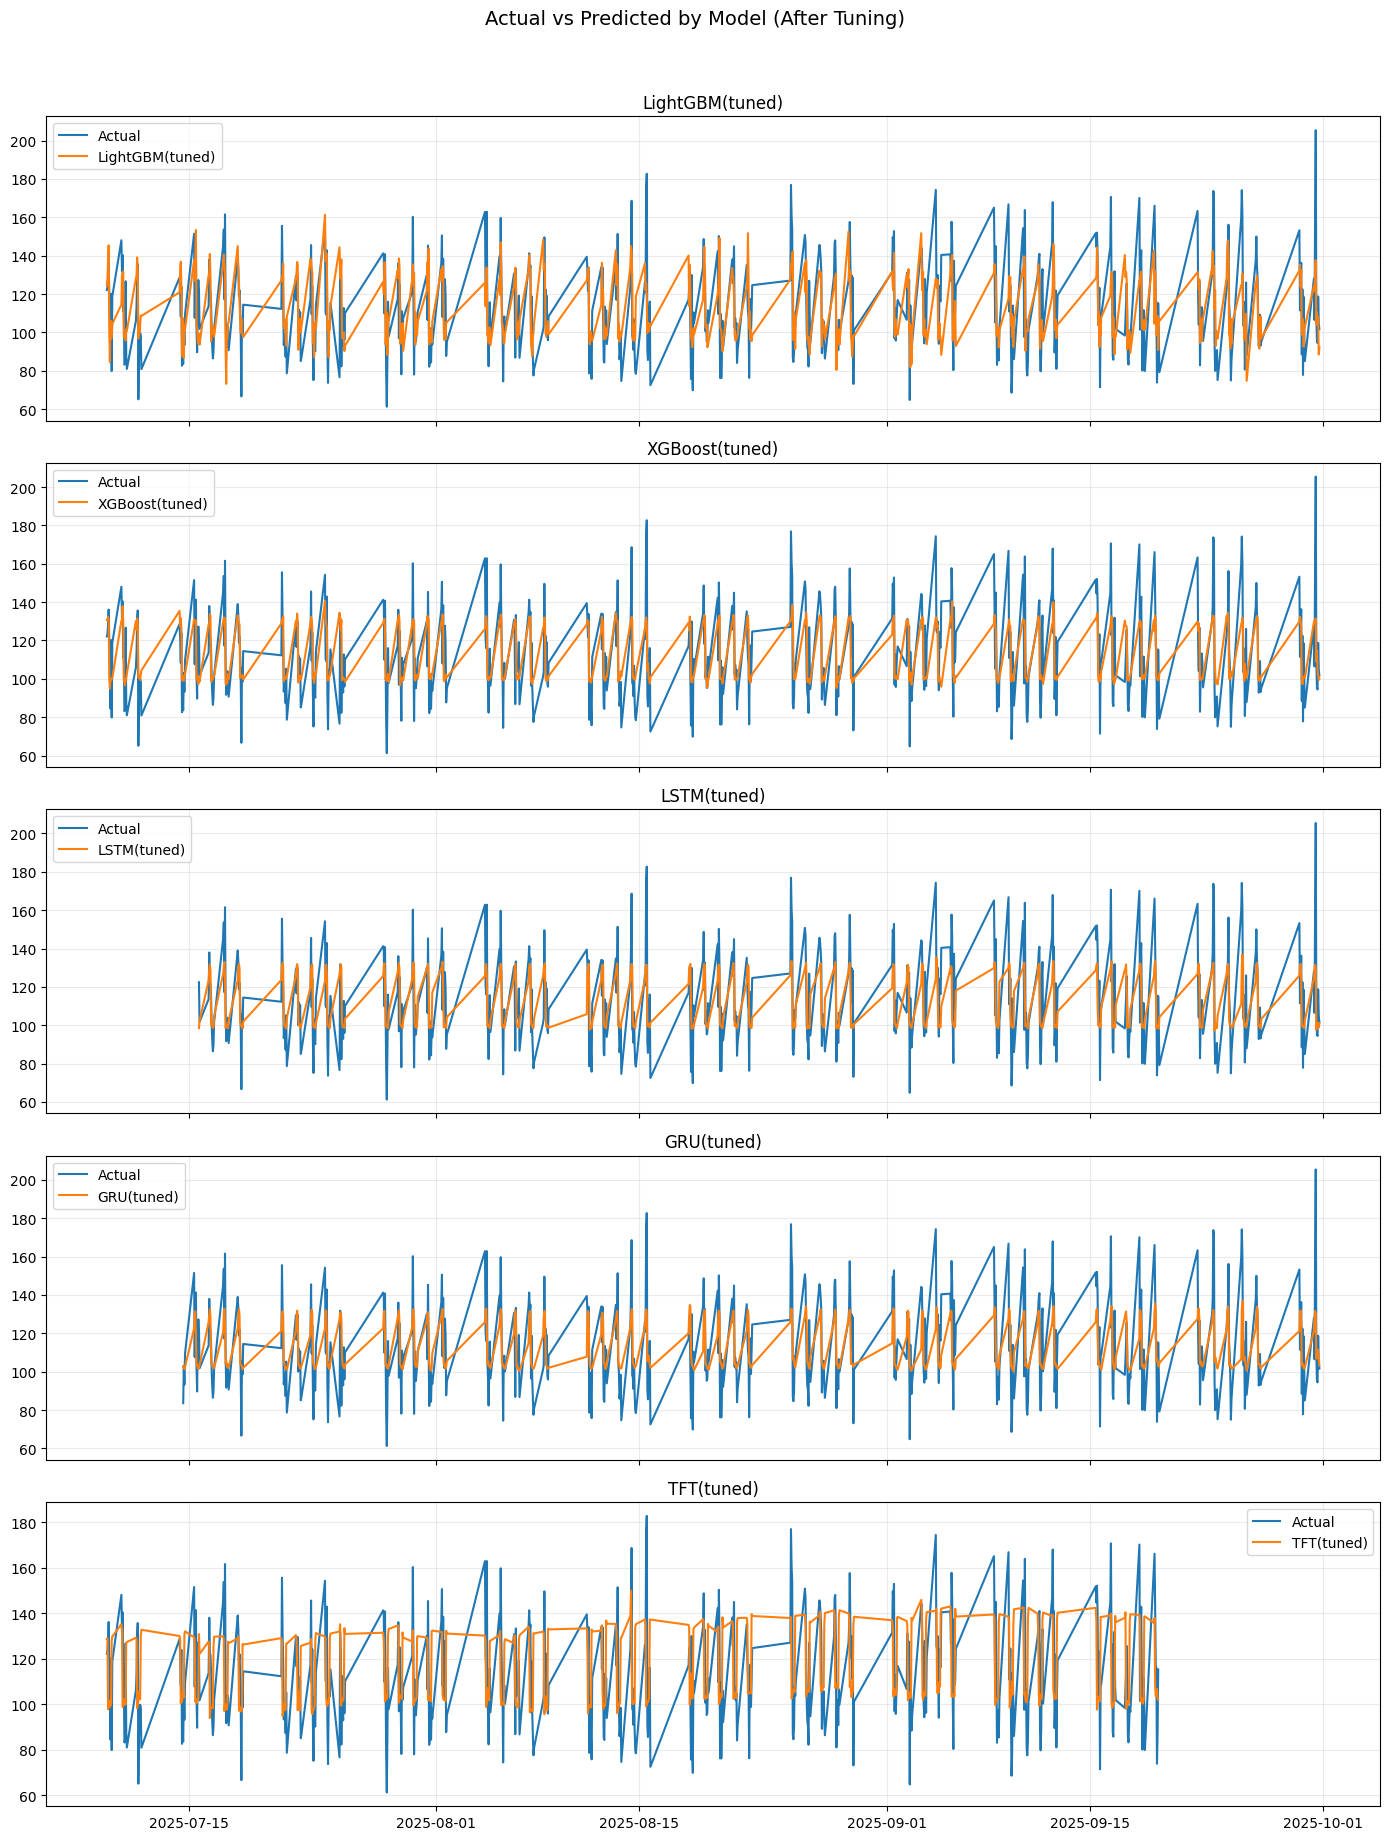

In [30]:
# === 셀 E: 튜닝 후 성능표 + 서브플롯 ===
rows_after = []
rows_after.append(("LightGBM(tuned)", *metrics_all(y_test_b.values, pred_lgb_tuned).values()))
rows_after.append(("XGBoost(tuned)",  *metrics_all(y_test_b.values, pred_xgb_tuned).values()))
rows_after.append(("LSTM(tuned)",     *metrics_all(y_test_seq_lstm, pred_lstm_tuned).values()))
rows_after.append(("GRU(tuned)",      *metrics_all(y_test_seq_gru,  pred_gru_tuned).values()))
rows_after.append(("TFT(tuned)",      *metrics_all(y_true_tft_test, tft_pred_series_tuned.values).values()))

perf_after = perf_table(rows_after)

display(perf_before.style.set_caption("Baseline Performance (before tuning)"))
display(perf_after.style.set_caption("Performance After Tuning"))

print("\n[Best Params Summary]")
print("LGBM:", best_params_lgb)
print("XGB :", best_params_xgb)
print("LSTM:", best_params_lstm)
print("GRU :", best_params_gru)
print("TFT :", best_params_tft)

# ---- 서브플롯: 튜닝 후 예측 비교 ----
import matplotlib.pyplot as plt
tail_n = 600

series_list = [
    ("LightGBM(tuned)", y_test_b.index, y_test_b.values, pred_lgb_tuned),
    ("XGBoost(tuned)",  y_test_b.index, y_test_b.values, pred_xgb_tuned),
    ("LSTM(tuned)",     test_df.index[best_params_lstm["window"]:], y_test_seq_lstm, pred_lstm_tuned),
    ("GRU(tuned)",      test_df.index[best_params_gru["window"]:],  y_test_seq_gru,  pred_gru_tuned),
    ("TFT(tuned)",      tft_pred_series_tuned.index, y_true_tft_test[:len(tft_pred_series_tuned)], tft_pred_series_tuned.values),
]

n = len(series_list)
fig, axes = plt.subplots(nrows=n, ncols=1, figsize=(14, 3.6*n), sharex=True)
if n==1: axes=[axes]

for ax, (name, idx, y_true, y_pred) in zip(axes, series_list):
    if len(idx) > tail_n:
        idx   = idx[-tail_n:]
        y_true= y_true[-tail_n:]
        y_pred= y_pred[-tail_n:]
    ax.plot(idx, y_true, label="Actual")
    ax.plot(idx, y_pred, label=name)
    ax.set_title(name); ax.grid(alpha=0.25); ax.legend()

fig.suptitle("Actual vs Predicted by Model (After Tuning)", y=1.02, fontsize=14)
plt.tight_layout(); plt.show()

# Ensemble!!!

In [31]:
import numpy as np
import pandas as pd
from sklearn.metrics import mean_squared_error, mean_absolute_error
from sklearn.linear_model import RidgeCV, LassoCV
import warnings
warnings.filterwarnings("ignore")

HOURS_PER_DAY = 10
VAL_DAYS_INNER = 20              # 내부 검증 기간(영업일) — 필요시 조정
VAL_LEN_INNER  = VAL_DAYS_INNER * HOURS_PER_DAY

def rmse(a, b):
    return float(mean_squared_error(a, b, squared=False))

# 내부 홀드아웃(시간 순서 유지)
X_tr_in  = X_train_b.iloc[:-VAL_LEN_INNER].copy()
y_tr_in  = y_train_b.iloc[:-VAL_LEN_INNER].copy()
X_val_in = X_train_b.iloc[-VAL_LEN_INNER:].copy()
y_val_in = y_train_b.iloc[-VAL_LEN_INNER:].copy()

# 재학습: LGB/XGB를 "베스트 파라미터"로 학습해 홀드아웃/테스트 예측을 만든다
def fit_lgb_xgb_for_ensemble(best_params_lgb, best_params_xgb):
    import lightgbm as lgb
    import xgboost as xgb

    # ---- LGBM
    lgb_tr = lgb.LGBMRegressor(**{**best_params_lgb, "random_state":42})
    try: lgb_tr.set_params(device="gpu")
    except: pass
    lgb_tr.fit(X_tr_in, y_tr_in,
               eval_set=[(X_val_in, y_val_in)],
               eval_metric="rmse",
               callbacks=[lgb.early_stopping(100, verbose=False)])
    pred_lgb_val = lgb_tr.predict(X_val_in)

    lgb_full = lgb.LGBMRegressor(**{**best_params_lgb, "random_state":42})
    try: lgb_full.set_params(device="gpu")
    except: pass
    lgb_full.fit(X_train_b, y_train_b)
    pred_lgb_test = lgb_full.predict(X_test_b)

    # ---- XGB
    xgb_tr = xgb.XGBRegressor(**{
        "objective":"reg:squarederror",
        "eval_metric":"rmse",
        "tree_method":"gpu_hist",
        "predictor":"gpu_predictor",
        **best_params_xgb, "random_state":42
    })
    xgb_tr.fit(X_tr_in, y_tr_in, eval_set=[(X_val_in, y_val_in)], verbose=False)
    pred_xgb_val = xgb_tr.predict(X_val_in)

    xgb_full = xgb.XGBRegressor(**{
        "objective":"reg:squarederror",
        "eval_metric":"rmse",
        "tree_method":"gpu_hist",
        "predictor":"gpu_predictor",
        **best_params_xgb, "random_state":42
    })
    xgb_full.fit(X_train_b, y_train_b, eval_set=[(X_test_b, y_test_b)], verbose=False)
    pred_xgb_test = xgb_full.predict(X_test_b)

    return (lgb_tr, xgb_tr, lgb_full, xgb_full,
            pred_lgb_val, pred_xgb_val, pred_lgb_test, pred_xgb_test)

(lgb_tr, xgb_tr, lgb_full, xgb_full,
 pred_lgb_val, pred_xgb_val, pred_lgb_test, pred_xgb_test) = fit_lgb_xgb_for_ensemble(best_params_lgb, best_params_xgb)

print("VAL RMSE  LGB:", rmse(y_val_in, pred_lgb_val), " / XGB:", rmse(y_val_in, pred_xgb_val))
print("TEST RMSE LGB:", rmse(y_test_b,  pred_lgb_test), " / XGB:", rmse(y_test_b,  pred_xgb_test))


[LightGBM] [Info] This is the GPU trainer!!
[LightGBM] [Info] Total Bins 2056
[LightGBM] [Info] Number of data points in the train set: 6346, number of used features: 10
[LightGBM] [Info] Using GPU Device: NVIDIA RTX A6000, Vendor: NVIDIA Corporation
[LightGBM] [Info] Compiling OpenCL Kernel with 256 bins...
[LightGBM] [Info] GPU programs have been built
[LightGBM] [Info] Size of histogram bin entry: 8
[LightGBM] [Info] 10 dense feature groups (0.07 MB) transferred to GPU in 0.000244 secs. 0 sparse feature groups
[LightGBM] [Info] Start training from score 134.218710
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positiv

In [32]:
# 그리드 서치로 가중치 w 탐색 (y ≈ w*xgb + (1-w)*lgb)
ws = np.linspace(0, 1, 101)
best_w, best_rmse = None, 1e9
for w in ws:
    pred_blend_val = w*pred_xgb_val + (1-w)*pred_lgb_val
    score = rmse(y_val_in, pred_blend_val)
    if score < best_rmse:
        best_rmse, best_w = score, w

# 테스트셋 적용
pred_blend_test = best_w*pred_xgb_test + (1-best_w)*pred_lgb_test

print(f"[Blending] best_w={best_w:.2f} | VAL_RMSE={best_rmse:.4f} | TEST_RMSE={rmse(y_test_b, pred_blend_test):.4f}")


[Blending] best_w=0.29 | VAL_RMSE=16.2895 | TEST_RMSE=18.0256


In [33]:
# 홀드아웃 단계의 잔차 학습
residual_val = y_val_in.values - pred_xgb_val
import lightgbm as lgb
lgb_res_tr = lgb.LGBMRegressor(
    n_estimators=best_params_lgb.get("n_estimators", 800),
    learning_rate=best_params_lgb.get("learning_rate", 0.05),
    num_leaves=best_params_lgb.get("num_leaves", 63),
    max_depth=best_params_lgb.get("max_depth", -1),
    subsample=best_params_lgb.get("subsample", 0.9),
    colsample_bytree=best_params_lgb.get("colsample_bytree", 0.8),
    random_state=42
)
try: lgb_res_tr.set_params(device="gpu")
except: pass
lgb_res_tr.fit(X_val_in, residual_val)

# 테스트 단계: XGB 예측 + LGB 잔차예측
pred_xgb_test_base = pred_xgb_test
residual_pred_test = lgb_res_tr.predict(X_test_b)
pred_residual_boost_test = pred_xgb_test_base + residual_pred_test

print("[Residual Boosting] TEST_RMSE:", rmse(y_test_b, pred_residual_boost_test))


[LightGBM] [Info] This is the GPU trainer!!
[LightGBM] [Info] Total Bins 560
[LightGBM] [Info] Number of data points in the train set: 200, number of used features: 10
[LightGBM] [Info] Using GPU Device: NVIDIA RTX A6000, Vendor: NVIDIA Corporation
[LightGBM] [Info] Compiling OpenCL Kernel with 256 bins...
[LightGBM] [Info] GPU programs have been built
[LightGBM] [Info] Size of histogram bin entry: 8
[LightGBM] [Info] 10 dense feature groups (0.00 MB) transferred to GPU in 0.000254 secs. 0 sparse feature groups
[LightGBM] [Info] Start training from score 1.380247
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive ga

In [34]:
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline

# 레벨-1 홀드아웃 특성
Z_val = np.column_stack([pred_xgb_val, pred_lgb_val])   # (N_val, 2)
Z_tst = np.column_stack([pred_xgb_test, pred_lgb_test]) # (N_test, 2)

# 메타 러너 (RidgeCV 또는 LassoCV)
alphas = np.logspace(-4, 2, 30)
meta_ridge = make_pipeline(StandardScaler(with_mean=False), RidgeCV(alphas=alphas, store_cv_values=False))
meta_ridge.fit(Z_val, y_val_in.values)
pred_stack_ridge_test = meta_ridge.predict(Z_tst)

meta_lasso = make_pipeline(StandardScaler(with_mean=False), LassoCV(alphas=alphas, max_iter=20000))
meta_lasso.fit(Z_val, y_val_in.values)
pred_stack_lasso_test = meta_lasso.predict(Z_tst)

print("[Stacking-Ridge] TEST_RMSE:", rmse(y_test_b, pred_stack_ridge_test))
print("[Stacking-Lasso] TEST_RMSE:", rmse(y_test_b, pred_stack_lasso_test))


[Stacking-Ridge] TEST_RMSE: 17.71308023405243
[Stacking-Lasso] TEST_RMSE: 18.043428699899174


,Model,MAE,RMSE,MAPE(%)
0,XGBoost(tuned),13.386448,17.136300,12.416747
1,Stacking (Ridge),13.728308,17.713080,12.792614
2,Blending (w=0.29),13.996152,18.025582,12.992069
3,Stacking (Lasso),14.013195,18.043429,13.011014
4,LightGBM(tuned),14.514426,18.683342,13.462253
5,Residual Boost (XGB + LGB),15.937959,20.292614,14.791003


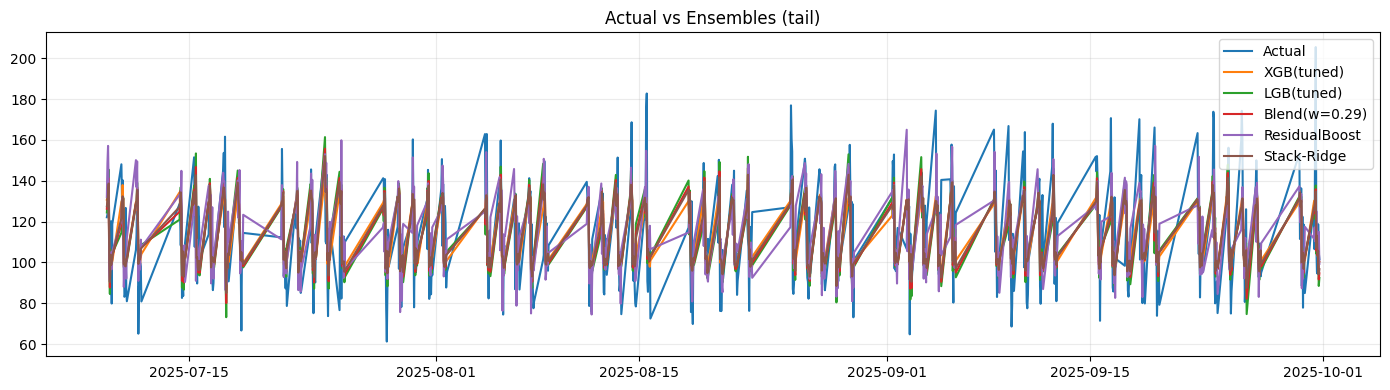

In [35]:
def metrics_row(name, y_true, y_pred):
    mae  = mean_absolute_error(y_true, y_pred)
    rmse_v = mean_squared_error(y_true, y_pred, squared=False)
    mape = float(np.mean(np.abs((y_true - y_pred) / np.maximum(1e-8, np.abs(y_true)))) * 100.0)
    return (name, mae, rmse_v, mape)

rows = []
# 단일 모델(튜닝된) — 참고용
rows.append(metrics_row("XGBoost(tuned)", y_test_b.values, pred_xgb_test))
rows.append(metrics_row("LightGBM(tuned)", y_test_b.values, pred_lgb_test))

# 앙상블 3종
rows.append(metrics_row(f"Blending (w={best_w:.2f})", y_test_b.values, pred_blend_test))
rows.append(metrics_row("Residual Boost (XGB + LGB)", y_test_b.values, pred_residual_boost_test))
rows.append(metrics_row("Stacking (Ridge)", y_test_b.values, pred_stack_ridge_test))
rows.append(metrics_row("Stacking (Lasso)", y_test_b.values, pred_stack_lasso_test))

perf_ens = pd.DataFrame(rows, columns=["Model","MAE","RMSE","MAPE(%)"]).sort_values("RMSE").reset_index(drop=True)
display(perf_ens.style.set_caption("Ensemble vs Single Models on Test"))

# 서브플롯 (최근 600포인트)
import matplotlib.pyplot as plt
tail_n = 600
idx = y_test_b.index[-tail_n:]
yt  = y_test_b.values[-tail_n:]

plt.figure(figsize=(14,4))
plt.plot(idx, yt, label="Actual")
plt.plot(idx, pred_xgb_test[-tail_n:], label="XGB(tuned)")
plt.plot(idx, pred_lgb_test[-tail_n:], label="LGB(tuned)")
plt.plot(idx, pred_blend_test[-tail_n:], label=f"Blend(w={best_w:.2f})")
plt.plot(idx, pred_residual_boost_test[-tail_n:], label="ResidualBoost")
plt.plot(idx, pred_stack_ridge_test[-tail_n:], label="Stack-Ridge")
plt.legend(); plt.grid(alpha=0.25); plt.title("Actual vs Ensembles (tail)")
plt.tight_layout(); plt.show()
